In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn import preprocessing
from torch.utils.data import Dataset, DataLoader
import scipy.sparse as sp
import scipy.stats
from sklearn.metrics import r2_score  
import matplotlib.pyplot as plt

In [2]:
def induce_sparsity(df, row_frac=0.2, col_n=2, seed=None):
    df_sparse = df.copy()
    mutations_removed = df_sparse.sample(frac=row_frac, random_state=seed).index #rows
    conditions_removed = df_sparse.sample(n=col_n, axis=1, random_state=seed).columns #columns
    df_sparse.loc[mutations_removed, conditions_removed] = np.nan
    return df_sparse, mutations_removed, conditions_removed

def mean_impute_by_row(data):
    if isinstance(data, pd.DataFrame):
        data = data.select_dtypes(include=[np.number]).values.astype(float)

    row_means = np.nanmean(data, axis=1)
    inds = np.where(np.isnan(data))
    data[inds] = row_means[inds[0]]
    return data

def prepare_vae_data(df_sparse, original_df):
    df_numeric_sparse = df_sparse.select_dtypes(include=[np.number])
    df_numeric_original = original_df[df_numeric_sparse.columns]
    data_array = df_numeric_sparse.values.astype(float)
    original_array = df_numeric_original.values.astype(float)

    # Only create a mask for values that were NOT NaN in original, but ARE NaN now, the induced ones
    induced_mask = np.isnan(data_array) & ~np.isnan(original_array)
    data_filled = mean_impute_by_row(data_array)
    X = torch.tensor(data_filled, dtype=torch.float32)
    mask = torch.tensor(induced_mask, dtype=torch.bool)

    return X, mask, df_numeric_sparse.columns

def reconstruct_dataframe(model, X_tensor, numeric_cols, original_df):
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(X_tensor)
        recon_np = recon.numpy()
    
    df_reconstructed = original_df.copy()
    df_reconstructed[numeric_cols] = recon_np
    return df_reconstructed

def masked_mse_loss(reconstructed, original, mask):
    loss = ((reconstructed - original)**2)[mask].mean()
    return loss



In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE2(nn.Module):
    def __init__(self, input_dim, latent_dim=10, hidden_dim=64):
        super(VAE2, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim,hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = torch.tanh(self.fc1(x))
        h2 = torch.tanh(self.fc2(h1))
        mu = self.fc_mu(h1)
        logvar = self.fc_logvar(h2)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.tanh(self.fc3(z))
        h4 = torch.tanh(self.fc4(h3))
        return self.fc5(h4)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
def vae_loss(recon_x, x, mu, logvar,mask, kl_weight=0.005):
    recon_loss = ((recon_x - x) ** 2)[mask].mean()
    kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_weight * kl_div, recon_loss,kl_div

###THESE ARE THE CORRECT ONES!!!
def prepare_vae_data(df_sparse, original_df):
    df_numeric_sparse = df_sparse.select_dtypes(include=[np.number])
    df_numeric_original = original_df[df_numeric_sparse.columns]
    data_array = df_numeric_sparse.values.astype(float)
    original_array = df_numeric_original.values.astype(float)

    induced_mask = np.isnan(data_array) & ~np.isnan(original_array) # masks(selects) only the values that were set no Nan
     # Everything that was originally not NaN (all values but original na (inclidiong the original values of the imputations))

    training_mask = ~np.isnan(original_array) & ~np.isnan(data_array)  # excludes induced NaNs

    data_filled = mean_impute_by_row(data_array) #imputing with the mean values of each row
    X = torch.tensor(data_filled, dtype=torch.float32)
    induced_mask = torch.tensor(induced_mask, dtype=torch.bool)
    training_mask = torch.tensor(training_mask, dtype=torch.bool)

    return X, induced_mask, training_mask, df_numeric_sparse.columns

def train_vae(model, X_tensor, training_mask, induced_mask, val_split=0.1, epochs=100, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()

    num_samples = X_tensor.size(0)
    num_val = int(val_split * num_samples)
    indices = torch.randperm(num_samples) #random select the indices of 10% of the data for validation
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]

    X_train = X_tensor[train_indices]
    real_mask_train = training_mask[train_indices] #Here we get the training set and the mask corresponding to this data

    X_val = X_tensor[val_indices]
    induced_mask_val = induced_mask[val_indices] #these 2 masks are for the loss computation of both the training and validation sets

    total_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        recon, mu, logvar = model(X_train)

        # Training loss only on real observed entries
        loss, recon_loss, kl = vae_loss(recon, X_train, mu, logvar, real_mask_train, kl_weight=0.01)
        loss.backward()
        optimizer.step()

        total_losses.append(loss.item())

        # Validation loss on induced missing entries
        model.eval()
        with torch.no_grad():
            recon_val, mu_val, logvar_val = model(X_val)
            val_loss, _, _ = vae_loss(recon_val, X_val, mu_val, logvar_val, induced_mask_val, kl_weight=0.01)
            val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: train_loss={loss.item():.4f}, val_loss={val_loss.item():.4f}")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(total_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Training and Validation Losses')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [5]:
seeds=[3, 7, 13, 42, 99, 123, 2024, 777, 11, 8, 323, 1234, 22, 10] #14
df=pd.read_csv('/Users/joanacorreia/Library/CloudStorage/GoogleDrive-joana.d.correia@tecnico.ulisboa.pt/Discos partilhados/Cancer Scanning manuscript 2024/data/4_Screen_zscores/MC/MC_zscores_pDNA.csv')
df_original = df.copy()
df_numeric = df.select_dtypes(include=[np.number])
print(df_original.isna().sum().sum(), "original values are NaN.")
df_sparse , mutations_removed, conditions_removed = induce_sparsity(df,row_frac=0.15, col_n=6,seed=3)
print(df_sparse.isna().sum().sum()-df_original.isna().sum().sum(), "values were set to NaN")
print('Total non Nan values:', df_numeric.count().sum())
print(mutations_removed)

22608 original values are NaN.
40692 values were set to NaN
Total non Nan values: 926928
Index([16378, 33057,  8806, 29985,  4671, 24905, 14424,  1522, 18380,  4056,
       ...
       24794, 29441, 33659,  1434, 17609, 38490, 35949,  2623, 42445, 22208],
      dtype='int64', length=6782)


Epoch 0: train_loss=1.0209, val_loss=0.4065
Epoch 10: train_loss=0.8019, val_loss=0.2223
Epoch 20: train_loss=0.6790, val_loss=0.1609
Epoch 30: train_loss=0.5909, val_loss=0.1744
Epoch 40: train_loss=0.5243, val_loss=0.2585
Epoch 50: train_loss=0.4738, val_loss=0.1949
Epoch 60: train_loss=0.4122, val_loss=0.2081
Epoch 70: train_loss=0.3767, val_loss=0.2147
Epoch 80: train_loss=0.3527, val_loss=0.2040
Epoch 90: train_loss=0.3355, val_loss=0.1998
Epoch 100: train_loss=0.3238, val_loss=0.1999
Epoch 110: train_loss=0.3147, val_loss=0.1909
Epoch 120: train_loss=0.3073, val_loss=0.1911
Epoch 130: train_loss=0.3008, val_loss=0.1915
Epoch 140: train_loss=0.2959, val_loss=0.1918
Epoch 150: train_loss=0.2920, val_loss=0.1910
Epoch 160: train_loss=0.2882, val_loss=0.1951
Epoch 170: train_loss=0.2853, val_loss=0.1966
Epoch 180: train_loss=0.2826, val_loss=0.1922
Epoch 190: train_loss=0.2805, val_loss=0.1954
Epoch 200: train_loss=0.2781, val_loss=0.1966
Epoch 210: train_loss=0.2760, val_loss=0.1971

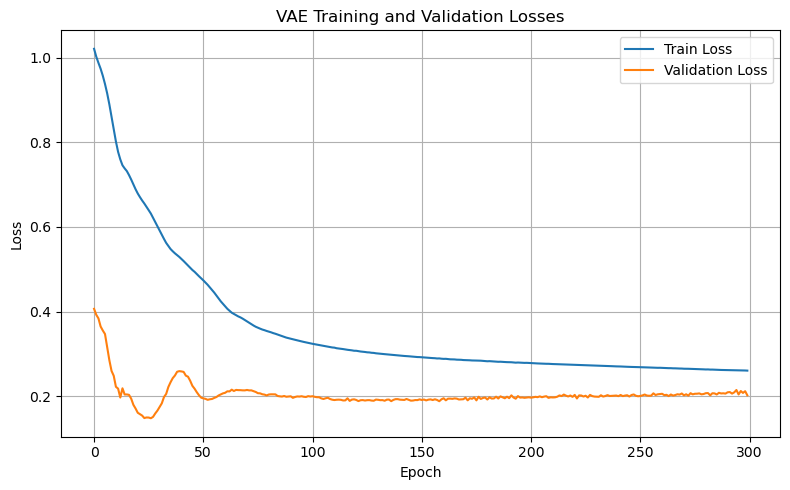

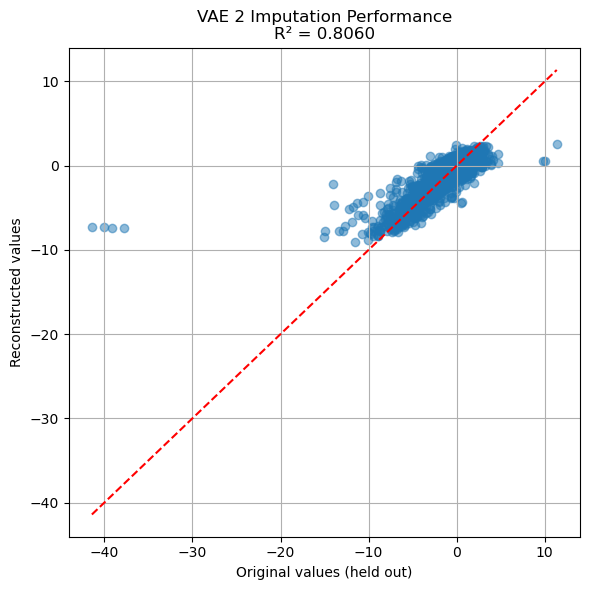

In [ ]:
torch.manual_seed(3)
X_tensor, induced_mask, training_mask, df_numeric_columns = prepare_vae_data(df_sparse, df_original)
vae2 = VAE2(input_dim=X_tensor.shape[1],latent_dim=4, hidden_dim=128)
train_vae(vae2, X_tensor, training_mask, induced_mask, val_split=0.1, epochs=300, lr=1e-3)

vae2.eval()
with torch.no_grad():
    reconstructed, _, _ = vae2(X_tensor)

df_numeric = df.select_dtypes(include=[np.number])
data_array = df_numeric.values.astype(float)
X_original = torch.tensor(data_array, dtype=torch.float32)

original_np = X_original[induced_mask]
reconstructed_np = reconstructed[induced_mask]
mask_np = induced_mask.numpy()

original_vals = original_np.numpy()
reconstructed_vals = reconstructed_np.numpy()
#r2 = r2_score(original_vals, reconstructed_vals)
r, _ = scipy.stats.pearsonr(original_vals.flatten(), reconstructed_vals.flatten())

plt.figure(figsize=(6, 6))
plt.scatter(original_vals, reconstructed_vals, alpha=0.5)
plt.plot([original_vals.min(), original_vals.max()],[original_vals.min(), original_vals.max()],'r--') 
plt.xlabel("Original values (held out)")
plt.ylabel("Reconstructed values")
plt.title(f"VAE 2 Imputation Performance\nR = {r:.4f}")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.show()

22608 original values are NaN.
40692 values were set to NaN
Total non Nan values: 926928
Epoch 0: train_loss=1.0287, val_loss=0.4064
Epoch 10: train_loss=0.8054, val_loss=0.2084
Epoch 20: train_loss=0.6869, val_loss=0.1440
Epoch 30: train_loss=0.5983, val_loss=0.1565
Epoch 40: train_loss=0.5267, val_loss=0.2219
Epoch 50: train_loss=0.4681, val_loss=0.1734
Epoch 60: train_loss=0.4146, val_loss=0.2054
Epoch 70: train_loss=0.3820, val_loss=0.2064
Epoch 80: train_loss=0.3604, val_loss=0.1955
Epoch 90: train_loss=0.3437, val_loss=0.1984
Epoch 100: train_loss=0.3315, val_loss=0.1937
Epoch 110: train_loss=0.3223, val_loss=0.1929
Epoch 120: train_loss=0.3145, val_loss=0.1961
Epoch 130: train_loss=0.3080, val_loss=0.1944
Epoch 140: train_loss=0.3031, val_loss=0.1952
Epoch 150: train_loss=0.2991, val_loss=0.1994
Epoch 160: train_loss=0.2954, val_loss=0.1965
Epoch 170: train_loss=0.2924, val_loss=0.2007
Epoch 180: train_loss=0.2897, val_loss=0.2004
Epoch 190: train_loss=0.2873, val_loss=0.2043
Ep

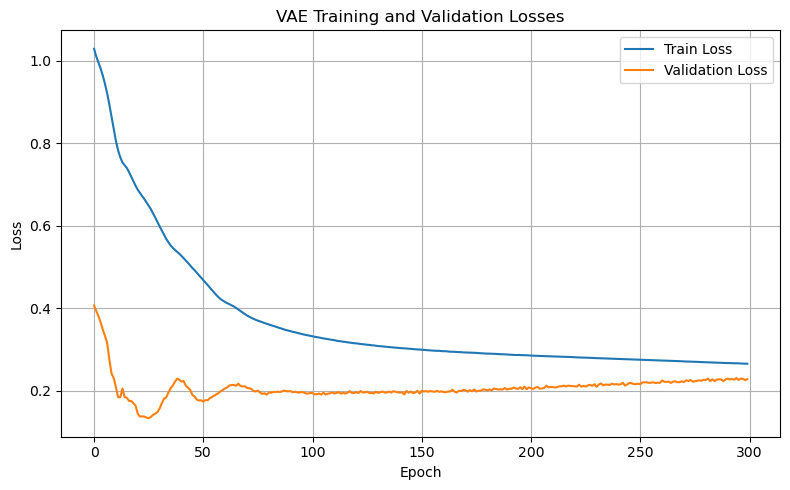

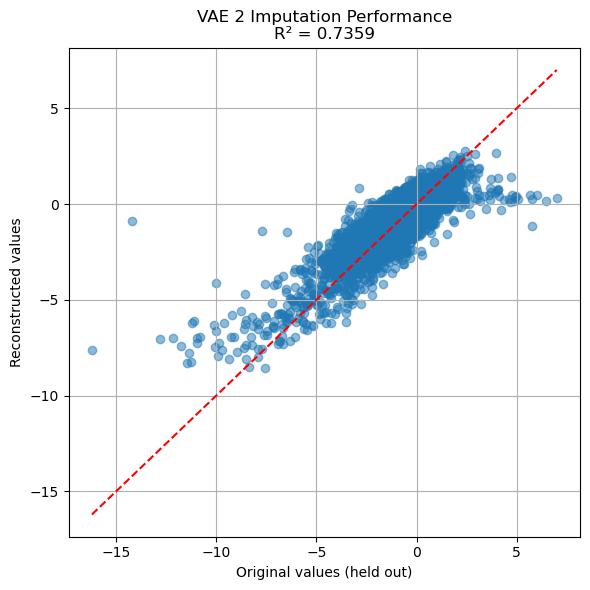

In [20]:

df=pd.read_csv('/Users/joanacorreia/Library/CloudStorage/GoogleDrive-joana.d.correia@tecnico.ulisboa.pt/Discos partilhados/Cancer Scanning manuscript 2024/data/4_Screen_zscores/MC/MC_zscores_pDNA.csv')
df_original = df.copy()
df_numeric = df.select_dtypes(include=[np.number])
print(df_original.isna().sum().sum(), "original values are NaN.")
df_sparse , mutations_removed, conditions_removed = induce_sparsity(df,row_frac=0.15, col_n=6, seed=42)
print(df_sparse.isna().sum().sum()-df_original.isna().sum().sum(), "values were set to NaN")
print('Total non Nan values:', df_numeric.count().sum())

torch.manual_seed(3)
X_tensor, induced_mask, training_mask, df_numeric_columns = prepare_vae_data(df_sparse, df_original)
vae2 = VAE2(input_dim=X_tensor.shape[1],latent_dim=4, hidden_dim=128)
train_vae(vae2, X_tensor, training_mask, induced_mask, val_split=0.1, epochs=300, lr=1e-3)

vae2.eval()
with torch.no_grad():
    reconstructed, _, _ = vae2(X_tensor)

df_numeric = df.select_dtypes(include=[np.number])
data_array = df_numeric.values.astype(float)
X_original = torch.tensor(data_array, dtype=torch.float32)

original_np = X_original[induced_mask]
reconstructed_np = reconstructed[induced_mask]
mask_np = induced_mask.numpy()

original_vals = original_np.numpy()
reconstructed_vals = reconstructed_np.numpy()
r2 = r2_score(original_vals, reconstructed_vals)

plt.figure(figsize=(6, 6))
plt.scatter(original_vals, reconstructed_vals, alpha=0.5)
plt.plot([original_vals.min(), original_vals.max()],[original_vals.min(), original_vals.max()],'r--') 
plt.xlabel("Original values (held out)")
plt.ylabel("Reconstructed values")
plt.title(f"VAE 2 Imputation Performance\nR² = {r2:.4f}")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
seeds=[3, 7, 13, 42, 99, 123, 2024, 777, 11, 8, 323, 1234, 22, 10] #14
df=pd.read_csv('/Users/joanacorreia/Library/CloudStorage/GoogleDrive-joana.d.correia@tecnico.ulisboa.pt/Discos partilhados/Cancer Scanning manuscript 2024/data/4_Screen_zscores/MC/MC_zscores_pDNA.csv')
df_original = df.copy()
df_numeric = df.select_dtypes(include=[np.number])
print(df_original.isna().sum().sum(), "original values are NaN.")
totalr=[]
for seed in seeds:

    df_sparse , mutations_removed, conditions_removed = induce_sparsity(df,row_frac=0.2, col_n=6,seed=seed)
    print(df_sparse.isna().sum().sum()-df_original.isna().sum().sum(), "values were set to NaN")
    print('Total non Nan values:', df_numeric.count().sum())
    print(mutations_removed)



    torch.manual_seed(seed)
    X_tensor, induced_mask, training_mask, df_numeric_columns = prepare_vae_data(df_sparse, df_original)
    vae2 = VAE2(input_dim=X_tensor.shape[1],latent_dim=4, hidden_dim=128)
    train_vae(vae2, X_tensor, training_mask, induced_mask, val_split=0.1, epochs=300, lr=1e-3)

    vae2.eval()
    with torch.no_grad():
        reconstructed, _, _ = vae2(X_tensor)

    df_numeric = df.select_dtypes(include=[np.number])
    data_array = df_numeric.values.astype(float)
    X_original = torch.tensor(data_array, dtype=torch.float32)

    original_np = X_original[induced_mask]
    reconstructed_np = reconstructed[induced_mask]
    mask_np = induced_mask.numpy()

    original_vals = original_np.numpy()
    reconstructed_vals = reconstructed_np.numpy()
    #r2 = r2_score(original_vals, reconstructed_vals)
    r, _ = scipy.stats.pearsonr(original_vals.flatten(), reconstructed_vals.flatten())
    totalr.append(r)
    plt.figure(figsize=(6, 6))
    plt.scatter(original_vals, reconstructed_vals, alpha=0.5)
    plt.plot([original_vals.min(), original_vals.max()],[original_vals.min(), original_vals.max()],'r--') 
    plt.xlabel("Original values (held out)")
    plt.ylabel("Reconstructed values")
    plt.title(f"VAE 2 Imputation Performance\nR = {r:.4f}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.show()
average_r = np.mean(totalr)
print(f"\nAverage Pearson R over {len(seeds)} seeds: {average_r:.4f}")

In [11]:
print(f"\nAverage Pearson R over {len(seeds)} seeds: {average_r:.4f}")


Average Pearson R over 14 seeds: 0.8027


22608 original values are NaN.
226080 values were set to NaN
Total non Nan values: 926928
Index([16378, 33057,  8806, 29985,  4671, 24905, 14424,  1522, 18380,  4056,
       ...
       30895,  2435,  5317, 44380, 25392, 39101, 36035, 18487, 40020,  9403],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0185, val_loss=0.4348
Epoch 10: train_loss=0.7944, val_loss=0.2300
Epoch 20: train_loss=0.6739, val_loss=0.1692
Epoch 30: train_loss=0.5820, val_loss=0.1813
Epoch 40: train_loss=0.5179, val_loss=0.2557
Epoch 50: train_loss=0.4525, val_loss=0.1934
Epoch 60: train_loss=0.3978, val_loss=0.2123
Epoch 70: train_loss=0.3633, val_loss=0.2176
Epoch 80: train_loss=0.3439, val_loss=0.2260
Epoch 90: train_loss=0.3276, val_loss=0.2239
Epoch 100: train_loss=0.3155, val_loss=0.2278
Epoch 110: train_loss=0.3062, val_loss=0.2330
Epoch 120: train_loss=0.2987, val_loss=0.2381
Epoch 130: train_loss=0.2918, val_loss=0.2396
Epoch 140: train_loss=0.2865, val_loss=0.2403
Epoch 150: train_loss=0.2815, 

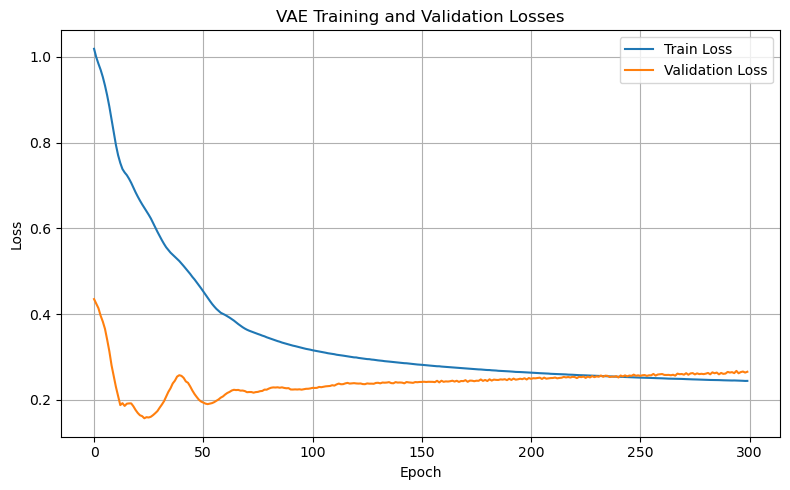

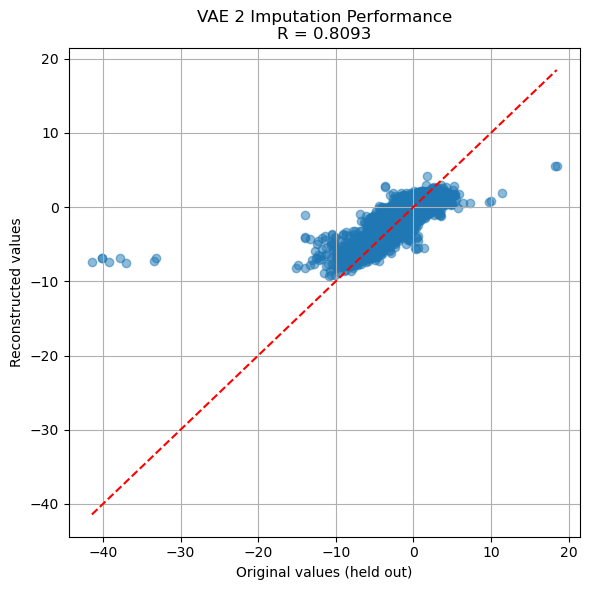

226080 values were set to NaN
Total non Nan values: 926928
Index([33180,  1544, 25860, 27946, 30199, 34996, 10563, 22824, 15438, 37829,
       ...
       38555, 15198, 10842, 44323, 41646, 23094, 24056,  8977, 14321, 24095],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0289, val_loss=0.4722
Epoch 10: train_loss=0.8033, val_loss=0.2475
Epoch 20: train_loss=0.6636, val_loss=0.1813
Epoch 30: train_loss=0.5621, val_loss=0.2154
Epoch 40: train_loss=0.5060, val_loss=0.2174
Epoch 50: train_loss=0.4474, val_loss=0.2017
Epoch 60: train_loss=0.4073, val_loss=0.2209
Epoch 70: train_loss=0.3748, val_loss=0.2082
Epoch 80: train_loss=0.3561, val_loss=0.2215
Epoch 90: train_loss=0.3401, val_loss=0.2180
Epoch 100: train_loss=0.3278, val_loss=0.2169
Epoch 110: train_loss=0.3176, val_loss=0.2206
Epoch 120: train_loss=0.3089, val_loss=0.2220
Epoch 130: train_loss=0.3019, val_loss=0.2285
Epoch 140: train_loss=0.2959, val_loss=0.2300
Epoch 150: train_loss=0.2902, val_loss=0.2336
Epoch 160: trai

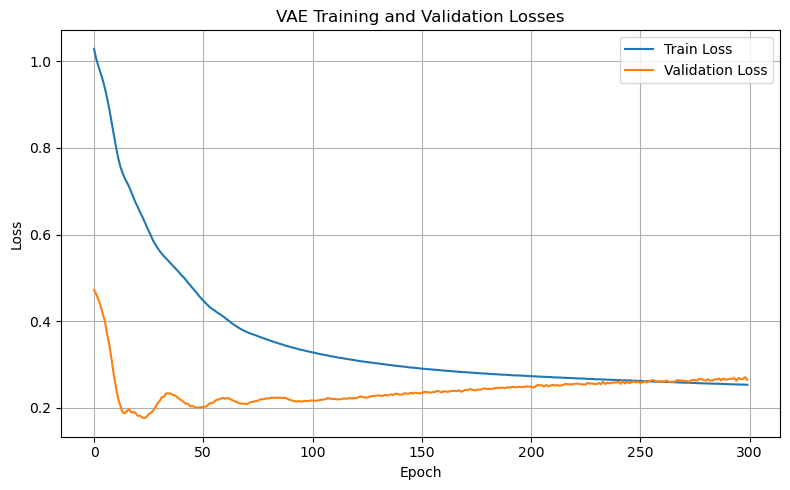

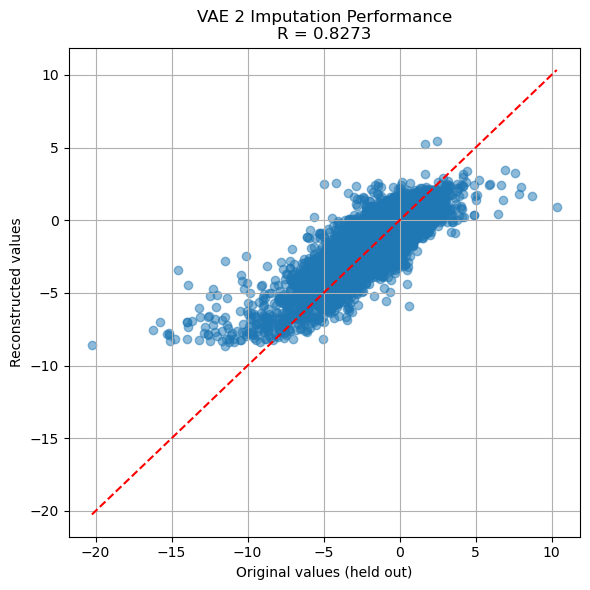

226080 values were set to NaN
Total non Nan values: 926928
Index([16159, 11807, 19922, 17897, 28017, 21241, 36855, 22738,  8793, 43170,
       ...
       10318, 12217,  5346, 17117,   717, 22360, 43042, 38248, 35702, 14927],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0254, val_loss=0.5371
Epoch 10: train_loss=0.7939, val_loss=0.3398
Epoch 20: train_loss=0.6661, val_loss=0.2368
Epoch 30: train_loss=0.5874, val_loss=0.2227
Epoch 40: train_loss=0.5098, val_loss=0.2822
Epoch 50: train_loss=0.4439, val_loss=0.2495
Epoch 60: train_loss=0.4047, val_loss=0.2797
Epoch 70: train_loss=0.3713, val_loss=0.2524
Epoch 80: train_loss=0.3484, val_loss=0.2615
Epoch 90: train_loss=0.3300, val_loss=0.2638
Epoch 100: train_loss=0.3171, val_loss=0.2715
Epoch 110: train_loss=0.3067, val_loss=0.2714
Epoch 120: train_loss=0.2984, val_loss=0.2703
Epoch 130: train_loss=0.2918, val_loss=0.2701
Epoch 140: train_loss=0.2862, val_loss=0.2701
Epoch 150: train_loss=0.2814, val_loss=0.2714
Epoch 160: trai

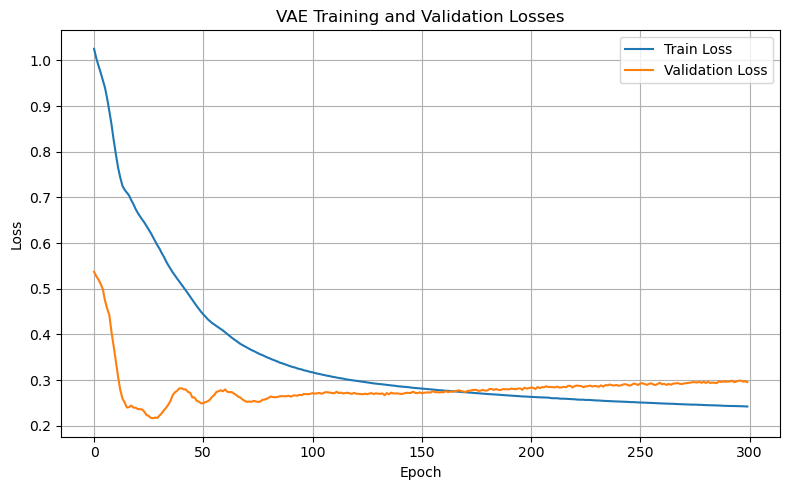

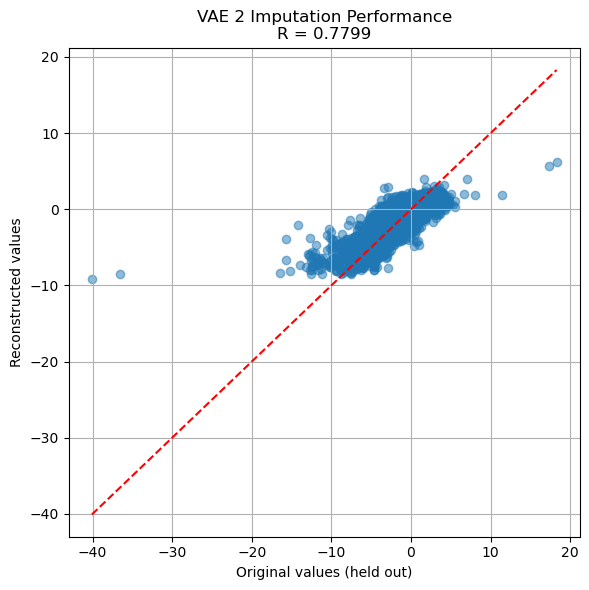

226080 values were set to NaN
Total non Nan values: 926928
Index([ 3776,  9928, 33411, 41896, 15738, 37089, 35466, 31384, 16904, 11930,
       ...
       16706, 43062, 43871, 35821, 38440, 16990, 31464,  9849, 25610,  4374],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0180, val_loss=0.4669
Epoch 10: train_loss=0.7718, val_loss=0.2399
Epoch 20: train_loss=0.6485, val_loss=0.1899
Epoch 30: train_loss=0.5516, val_loss=0.2201
Epoch 40: train_loss=0.4694, val_loss=0.2519
Epoch 50: train_loss=0.4269, val_loss=0.2581
Epoch 60: train_loss=0.3930, val_loss=0.2454
Epoch 70: train_loss=0.3649, val_loss=0.2480
Epoch 80: train_loss=0.3469, val_loss=0.2431
Epoch 90: train_loss=0.3313, val_loss=0.2484
Epoch 100: train_loss=0.3192, val_loss=0.2514
Epoch 110: train_loss=0.3094, val_loss=0.2647
Epoch 120: train_loss=0.3013, val_loss=0.2459
Epoch 130: train_loss=0.2943, val_loss=0.2442
Epoch 140: train_loss=0.2883, val_loss=0.2527
Epoch 150: train_loss=0.2832, val_loss=0.2457
Epoch 160: trai

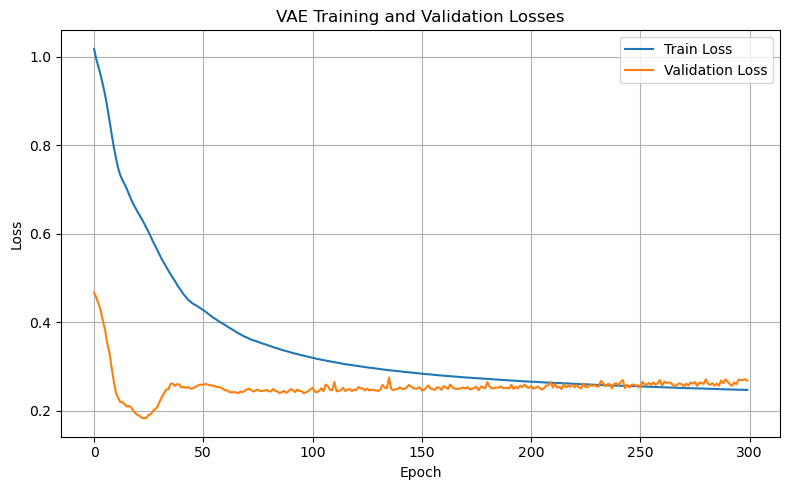

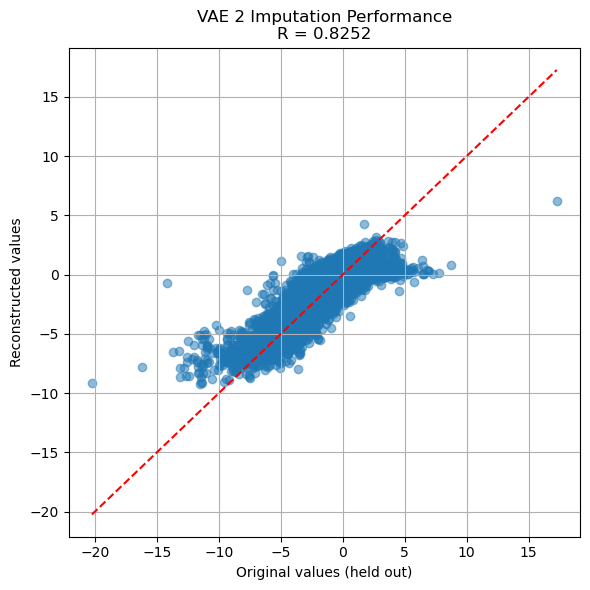

214819 values were set to NaN
Total non Nan values: 926928
Index([15638, 10798, 34315, 42356,  4923, 15025, 36095, 19088, 18739, 42347,
       ...
        9646,  3719,   695, 19685, 43487, 28588,  6018, 32615, 29447, 18125],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0101, val_loss=0.4482
Epoch 10: train_loss=0.7635, val_loss=0.2350
Epoch 20: train_loss=0.6695, val_loss=0.2017
Epoch 30: train_loss=0.5667, val_loss=0.1854
Epoch 40: train_loss=0.4852, val_loss=0.2236
Epoch 50: train_loss=0.4308, val_loss=0.2306
Epoch 60: train_loss=0.3939, val_loss=0.2608
Epoch 70: train_loss=0.3626, val_loss=0.2626
Epoch 80: train_loss=0.3445, val_loss=0.2695
Epoch 90: train_loss=0.3292, val_loss=0.2609
Epoch 100: train_loss=0.3179, val_loss=0.2577
Epoch 110: train_loss=0.3086, val_loss=0.2579
Epoch 120: train_loss=0.3015, val_loss=0.2643
Epoch 130: train_loss=0.2953, val_loss=0.2547
Epoch 140: train_loss=0.2905, val_loss=0.2659
Epoch 150: train_loss=0.2866, val_loss=0.2600
Epoch 160: trai

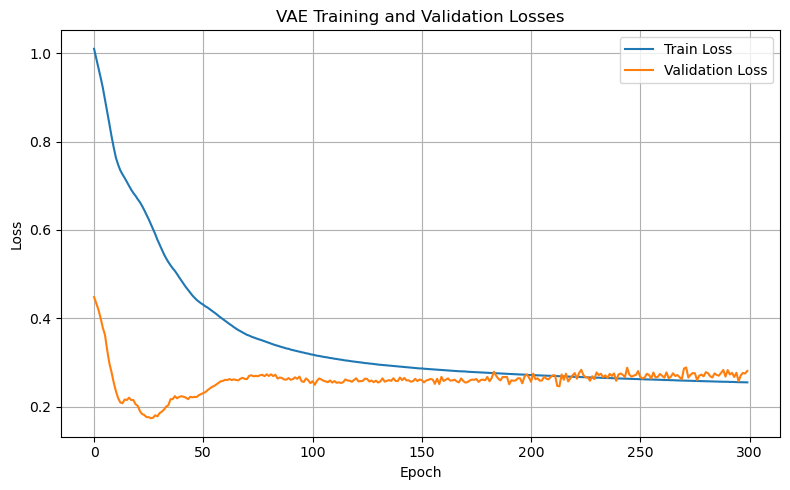

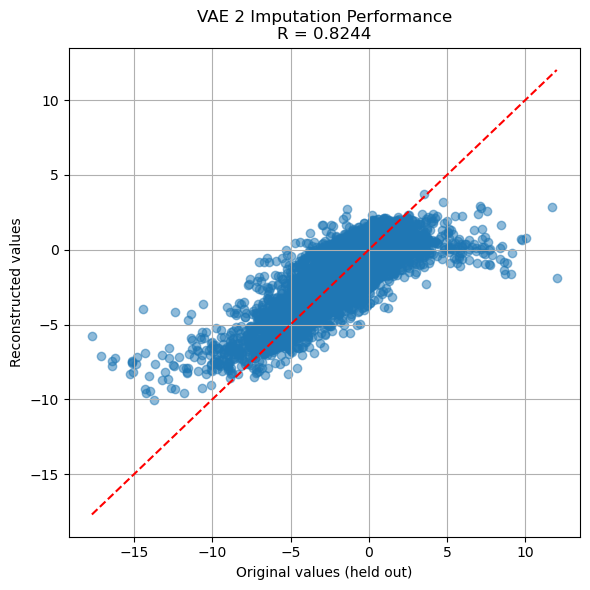

226080 values were set to NaN
Total non Nan values: 926928
Index([27848, 25245, 27507,  4795, 23864, 35667,  8907,  5573, 15187, 30127,
       ...
       24002,  9390,  8810, 22278, 23134, 17043, 44597, 24280, 23399, 36319],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0250, val_loss=0.4637
Epoch 10: train_loss=0.7819, val_loss=0.2235
Epoch 20: train_loss=0.6596, val_loss=0.1795
Epoch 30: train_loss=0.5564, val_loss=0.1986
Epoch 40: train_loss=0.5028, val_loss=0.1982
Epoch 50: train_loss=0.4617, val_loss=0.1782
Epoch 60: train_loss=0.4180, val_loss=0.1793
Epoch 70: train_loss=0.3823, val_loss=0.1872
Epoch 80: train_loss=0.3503, val_loss=0.1952
Epoch 90: train_loss=0.3330, val_loss=0.2053
Epoch 100: train_loss=0.3202, val_loss=0.2060
Epoch 110: train_loss=0.3104, val_loss=0.2043
Epoch 120: train_loss=0.3029, val_loss=0.2071
Epoch 130: train_loss=0.2958, val_loss=0.2086
Epoch 140: train_loss=0.2899, val_loss=0.2117
Epoch 150: train_loss=0.2851, val_loss=0.2127
Epoch 160: trai

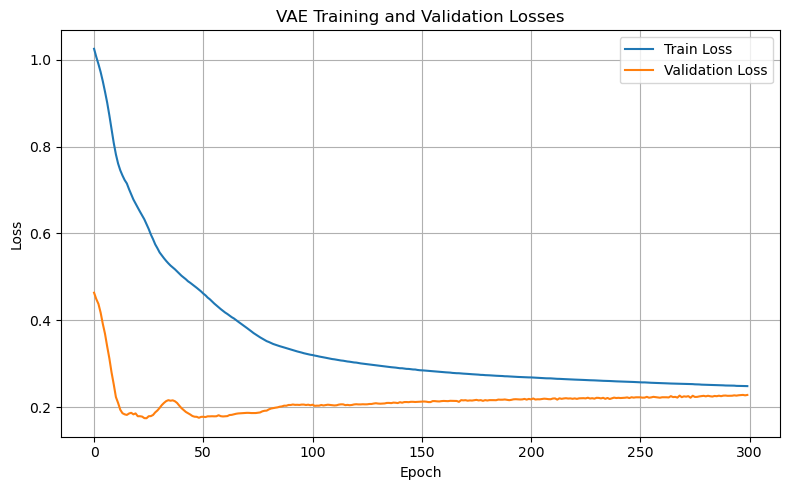

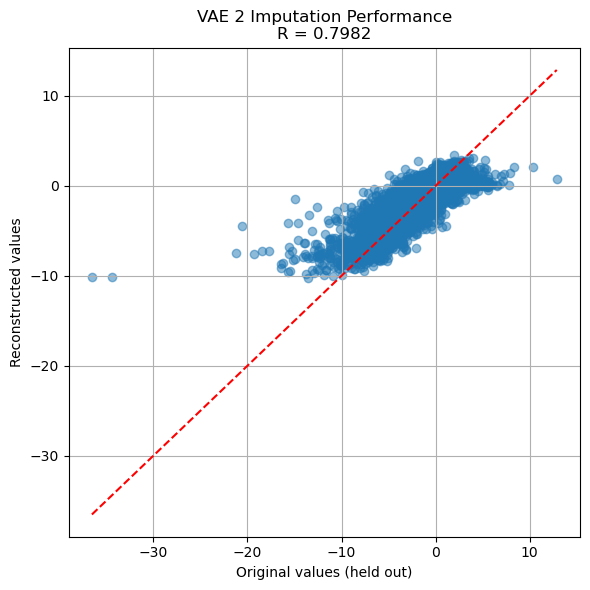

214812 values were set to NaN
Total non Nan values: 926928
Index([16806, 10593, 29122, 18880,   216, 34496, 17153, 34285,  1985,  3772,
       ...
       10120, 28983, 30406,  6775,  2181, 21146, 25706, 34054,  5935, 36570],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0263, val_loss=0.5306
Epoch 10: train_loss=0.7963, val_loss=0.3184
Epoch 20: train_loss=0.6725, val_loss=0.2228
Epoch 30: train_loss=0.5811, val_loss=0.2092
Epoch 40: train_loss=0.4738, val_loss=0.2563
Epoch 50: train_loss=0.4287, val_loss=0.2513
Epoch 60: train_loss=0.3967, val_loss=0.2329
Epoch 70: train_loss=0.3673, val_loss=0.2342
Epoch 80: train_loss=0.3454, val_loss=0.2333
Epoch 90: train_loss=0.3300, val_loss=0.2366
Epoch 100: train_loss=0.3181, val_loss=0.2369
Epoch 110: train_loss=0.3086, val_loss=0.2392
Epoch 120: train_loss=0.3008, val_loss=0.2397
Epoch 130: train_loss=0.2942, val_loss=0.2399
Epoch 140: train_loss=0.2882, val_loss=0.2416
Epoch 150: train_loss=0.2834, val_loss=0.2445
Epoch 160: trai

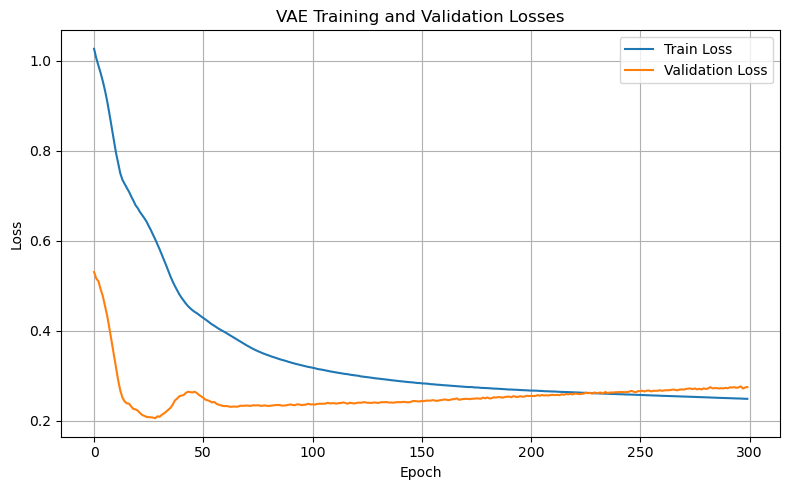

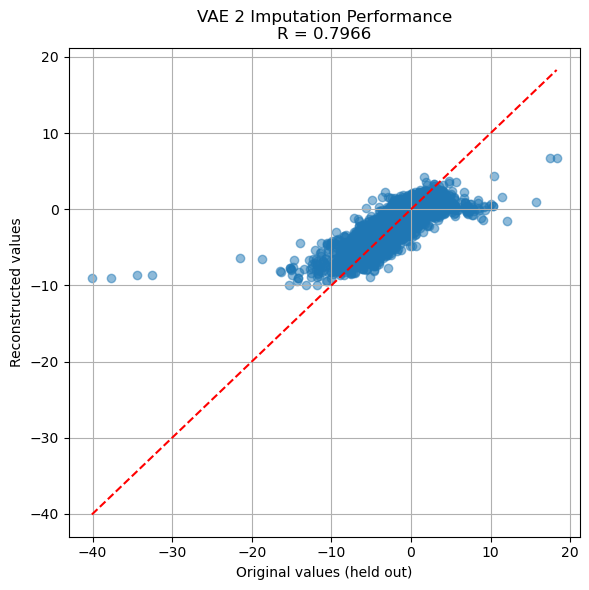

226080 values were set to NaN
Total non Nan values: 926928
Index([32884, 30176, 10167, 26633, 14875, 10528, 35116, 33299, 13039, 27379,
       ...
       32081, 10366, 42748,  7009, 15312, 22963, 36469,  4372, 41677, 21263],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0331, val_loss=0.4289
Epoch 10: train_loss=0.8024, val_loss=0.2273
Epoch 20: train_loss=0.6530, val_loss=0.1894
Epoch 30: train_loss=0.5541, val_loss=0.2099
Epoch 40: train_loss=0.5069, val_loss=0.1990
Epoch 50: train_loss=0.4609, val_loss=0.1901
Epoch 60: train_loss=0.4129, val_loss=0.2106
Epoch 70: train_loss=0.3837, val_loss=0.2176
Epoch 80: train_loss=0.3587, val_loss=0.2067
Epoch 90: train_loss=0.3390, val_loss=0.2135
Epoch 100: train_loss=0.3249, val_loss=0.2105
Epoch 110: train_loss=0.3145, val_loss=0.2117
Epoch 120: train_loss=0.3062, val_loss=0.2108
Epoch 130: train_loss=0.2993, val_loss=0.2123
Epoch 140: train_loss=0.2933, val_loss=0.2099
Epoch 150: train_loss=0.2883, val_loss=0.2105
Epoch 160: trai

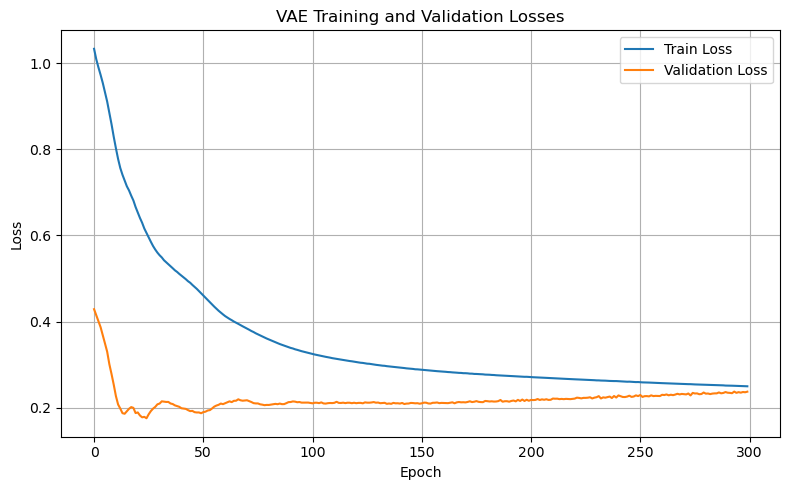

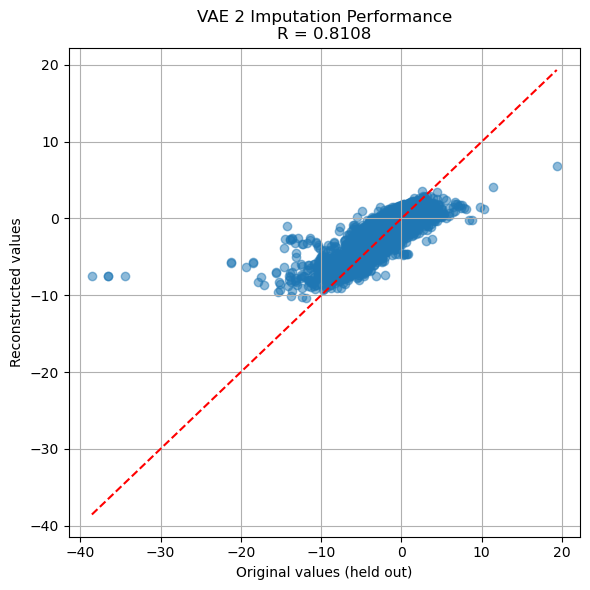

214775 values were set to NaN
Total non Nan values: 926928
Index([ 5630, 20258, 10111, 23846, 26684, 24479, 15273,   302, 17828, 35182,
       ...
       21437, 13838, 31351, 29153, 28462,   933, 38142, 28672, 34282, 43233],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0115, val_loss=0.5348
Epoch 10: train_loss=0.7613, val_loss=0.2865
Epoch 20: train_loss=0.6356, val_loss=0.2013
Epoch 30: train_loss=0.5345, val_loss=0.2402
Epoch 40: train_loss=0.4771, val_loss=0.2242
Epoch 50: train_loss=0.4315, val_loss=0.2129
Epoch 60: train_loss=0.3890, val_loss=0.2314
Epoch 70: train_loss=0.3584, val_loss=0.2362
Epoch 80: train_loss=0.3354, val_loss=0.2282
Epoch 90: train_loss=0.3191, val_loss=0.2207
Epoch 100: train_loss=0.3075, val_loss=0.2090
Epoch 110: train_loss=0.2978, val_loss=0.2052
Epoch 120: train_loss=0.2905, val_loss=0.2058
Epoch 130: train_loss=0.2840, val_loss=0.2065
Epoch 140: train_loss=0.2787, val_loss=0.2068
Epoch 150: train_loss=0.2742, val_loss=0.2077
Epoch 160: trai

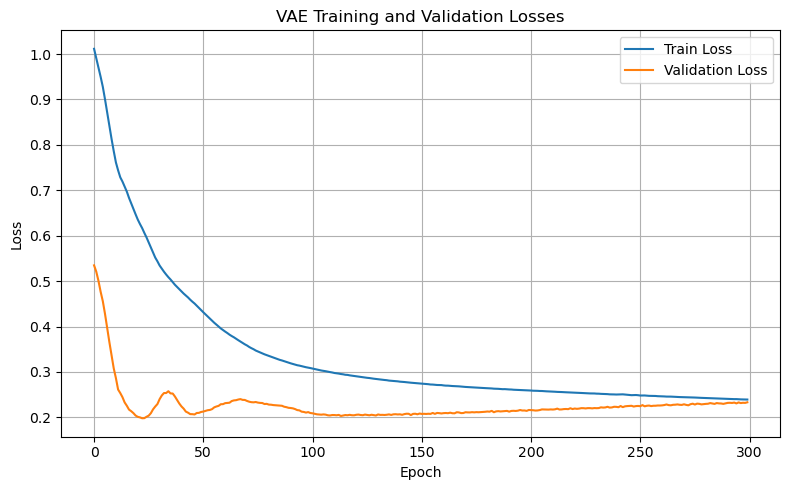

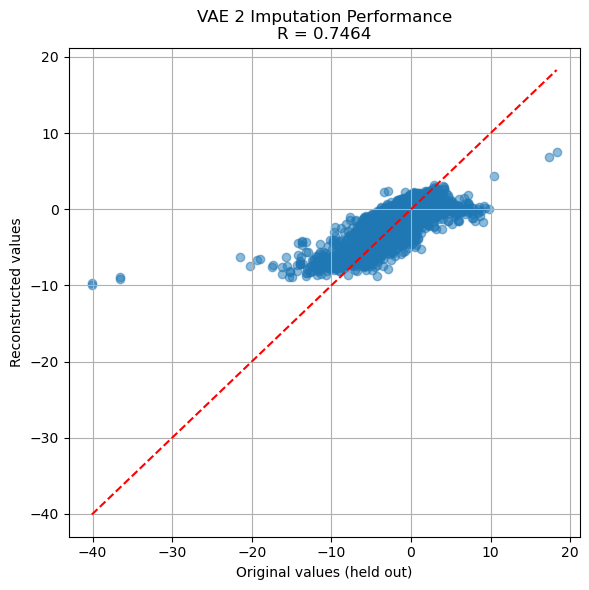

226080 values were set to NaN
Total non Nan values: 926928
Index([38499, 10196, 23677, 17783,  1376, 23204, 37330, 24250, 28032, 30742,
       ...
       15661, 18895, 43906, 30726, 22087, 32222, 13046, 28933, 27346, 29108],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0152, val_loss=0.4600
Epoch 10: train_loss=0.7552, val_loss=0.2335
Epoch 20: train_loss=0.6377, val_loss=0.2047
Epoch 30: train_loss=0.5498, val_loss=0.2459
Epoch 40: train_loss=0.5049, val_loss=0.2243
Epoch 50: train_loss=0.4629, val_loss=0.2204
Epoch 60: train_loss=0.4095, val_loss=0.2317
Epoch 70: train_loss=0.3772, val_loss=0.2320
Epoch 80: train_loss=0.3498, val_loss=0.2120
Epoch 90: train_loss=0.3274, val_loss=0.2238
Epoch 100: train_loss=0.3144, val_loss=0.2274
Epoch 110: train_loss=0.3032, val_loss=0.2232
Epoch 120: train_loss=0.2944, val_loss=0.2221
Epoch 130: train_loss=0.2877, val_loss=0.2253
Epoch 140: train_loss=0.2822, val_loss=0.2281
Epoch 150: train_loss=0.2773, val_loss=0.2306
Epoch 160: trai

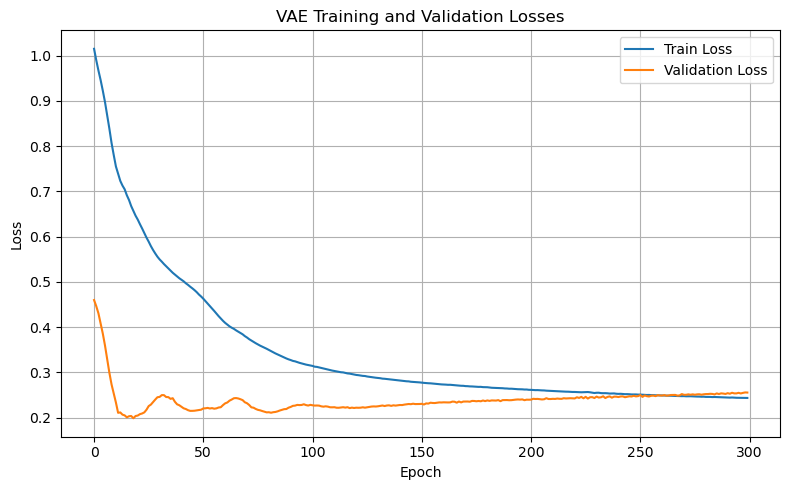

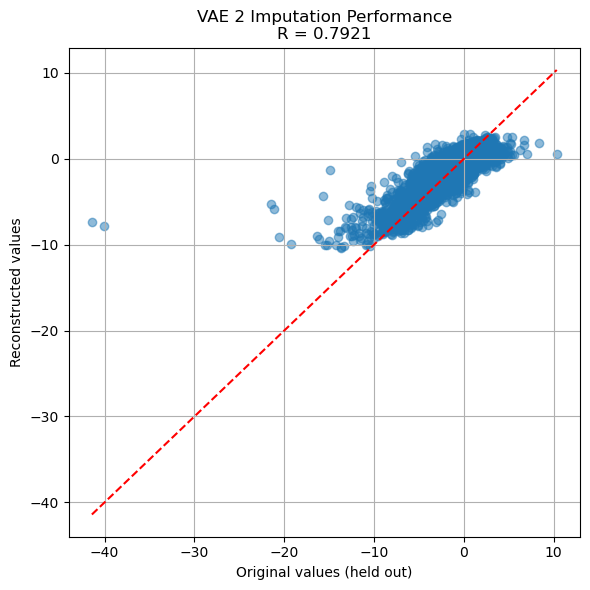

214782 values were set to NaN
Total non Nan values: 926928
Index([17617, 43971, 34035, 32315, 15193, 23872, 12538, 23293, 22059, 21910,
       ...
       33152, 39462, 17187, 29423,  8451, 26324, 29838, 25150,  8490,  7742],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0196, val_loss=0.4516
Epoch 10: train_loss=0.7576, val_loss=0.2530
Epoch 20: train_loss=0.6341, val_loss=0.2092
Epoch 30: train_loss=0.5473, val_loss=0.2518
Epoch 40: train_loss=0.4880, val_loss=0.2270
Epoch 50: train_loss=0.4307, val_loss=0.2460
Epoch 60: train_loss=0.3936, val_loss=0.2616
Epoch 70: train_loss=0.3640, val_loss=0.2661
Epoch 80: train_loss=0.3433, val_loss=0.2858
Epoch 90: train_loss=0.3275, val_loss=0.2752
Epoch 100: train_loss=0.3157, val_loss=0.2701
Epoch 110: train_loss=0.3069, val_loss=0.2688
Epoch 120: train_loss=0.3001, val_loss=0.2668
Epoch 130: train_loss=0.2943, val_loss=0.2641
Epoch 140: train_loss=0.2892, val_loss=0.2623
Epoch 150: train_loss=0.2850, val_loss=0.2636
Epoch 160: trai

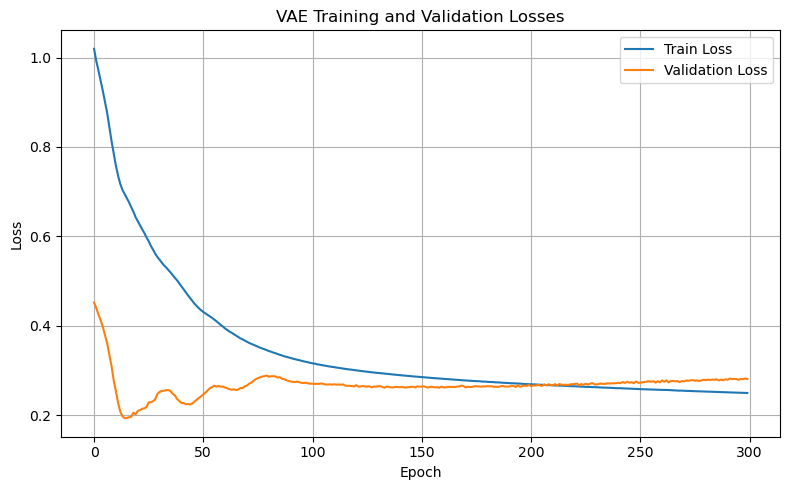

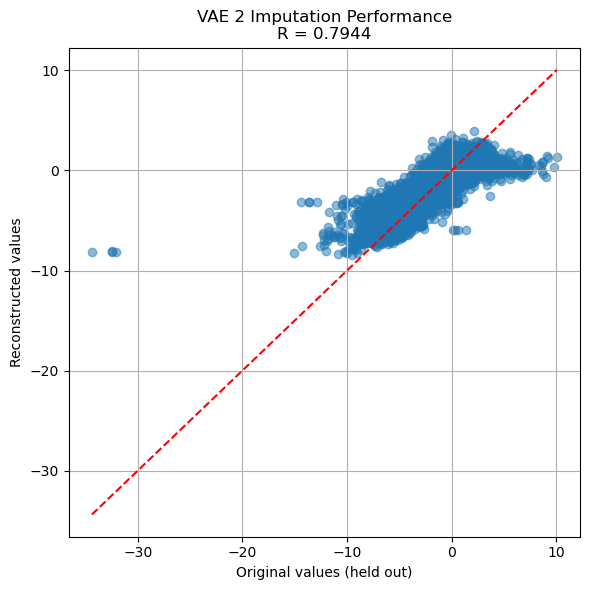

226080 values were set to NaN
Total non Nan values: 926928
Index([10329, 38964, 10889, 33407, 33955, 31567, 15591, 39432, 38454, 29480,
       ...
       29061, 43155, 43645, 32187, 32114, 15272, 39461, 20410, 14160, 36102],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0277, val_loss=0.5063
Epoch 10: train_loss=0.7663, val_loss=0.2894
Epoch 20: train_loss=0.6487, val_loss=0.2134
Epoch 30: train_loss=0.5557, val_loss=0.2071
Epoch 40: train_loss=0.4849, val_loss=0.2546
Epoch 50: train_loss=0.4275, val_loss=0.2393
Epoch 60: train_loss=0.3892, val_loss=0.2922
Epoch 70: train_loss=0.3584, val_loss=0.2589
Epoch 80: train_loss=0.3344, val_loss=0.2660
Epoch 90: train_loss=0.3184, val_loss=0.2742
Epoch 100: train_loss=0.3067, val_loss=0.2665
Epoch 110: train_loss=0.2968, val_loss=0.2616
Epoch 120: train_loss=0.2892, val_loss=0.2637
Epoch 130: train_loss=0.2829, val_loss=0.2629
Epoch 140: train_loss=0.2775, val_loss=0.2623
Epoch 150: train_loss=0.2726, val_loss=0.2615
Epoch 160: trai

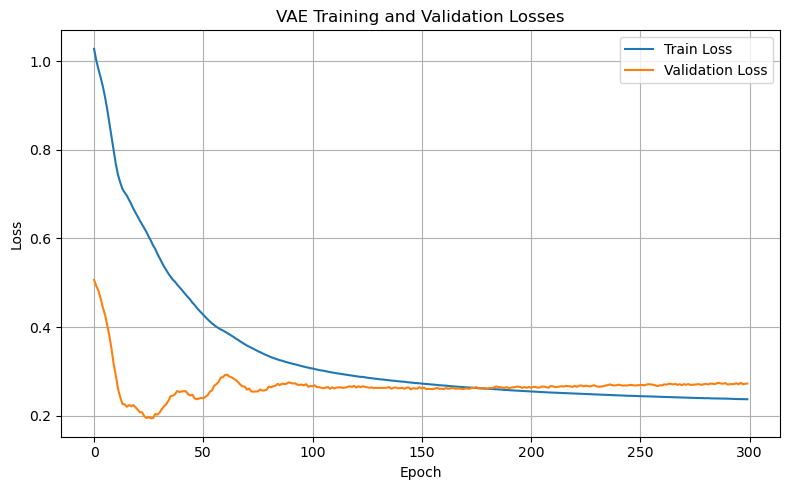

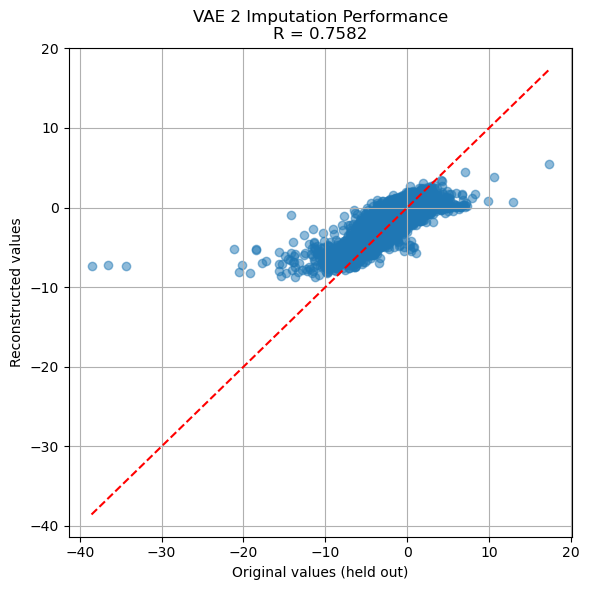

226080 values were set to NaN
Total non Nan values: 926928
Index([ 4793,  7650, 40013, 16743, 12188,   507, 37279, 44211, 31310, 31294,
       ...
       10984, 38861, 39223,  6445,  9374, 18218, 15645, 27638, 20362, 35334],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0258, val_loss=0.5309
Epoch 10: train_loss=0.7918, val_loss=0.3201
Epoch 20: train_loss=0.6597, val_loss=0.2381
Epoch 30: train_loss=0.5684, val_loss=0.2532
Epoch 40: train_loss=0.4962, val_loss=0.2438
Epoch 50: train_loss=0.4295, val_loss=0.2388
Epoch 60: train_loss=0.3791, val_loss=0.2695
Epoch 70: train_loss=0.3471, val_loss=0.2609
Epoch 80: train_loss=0.3260, val_loss=0.2472
Epoch 90: train_loss=0.3110, val_loss=0.2439
Epoch 100: train_loss=0.2994, val_loss=0.2358
Epoch 110: train_loss=0.2902, val_loss=0.2359
Epoch 120: train_loss=0.2830, val_loss=0.2346
Epoch 130: train_loss=0.2772, val_loss=0.2359
Epoch 140: train_loss=0.2724, val_loss=0.2389
Epoch 150: train_loss=0.2683, val_loss=0.2398
Epoch 160: trai

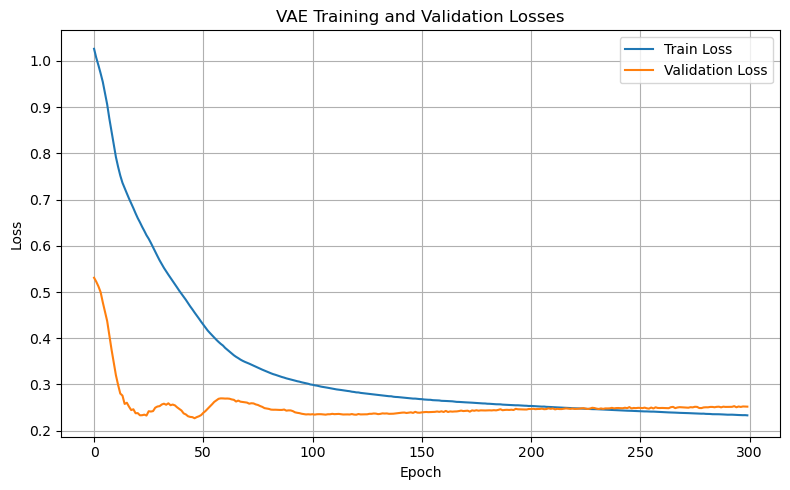

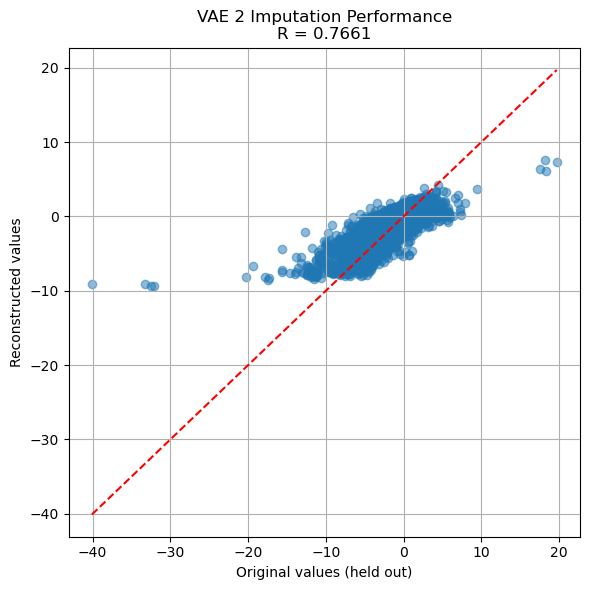

226080 values were set to NaN
Total non Nan values: 926928
Index([37280,  8403, 16544, 19900, 15498, 10375,  4001, 16969, 40084, 37991,
       ...
       29414,  6747,  8061, 23038, 15474,  1541, 32263,  3684, 22214, 15453],
      dtype='int64', length=22608)
Epoch 0: train_loss=1.0249, val_loss=0.5182
Epoch 10: train_loss=0.8211, val_loss=0.3282
Epoch 20: train_loss=0.6631, val_loss=0.2058
Epoch 30: train_loss=0.5771, val_loss=0.2111
Epoch 40: train_loss=0.4924, val_loss=0.2794
Epoch 50: train_loss=0.4249, val_loss=0.2544
Epoch 60: train_loss=0.3878, val_loss=0.2714
Epoch 70: train_loss=0.3547, val_loss=0.2359
Epoch 80: train_loss=0.3345, val_loss=0.2369
Epoch 90: train_loss=0.3190, val_loss=0.2433
Epoch 100: train_loss=0.3073, val_loss=0.2379
Epoch 110: train_loss=0.2977, val_loss=0.2392
Epoch 120: train_loss=0.2902, val_loss=0.2394
Epoch 130: train_loss=0.2837, val_loss=0.2409
Epoch 140: train_loss=0.2789, val_loss=0.2401
Epoch 150: train_loss=0.2746, val_loss=0.2413
Epoch 160: trai

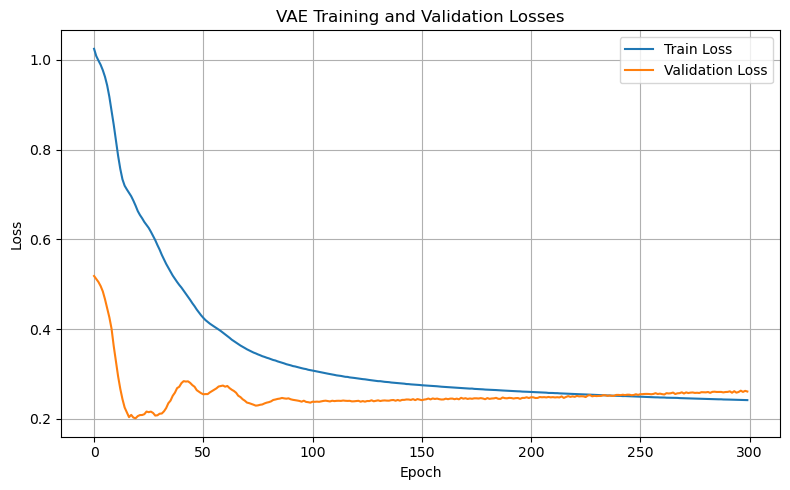

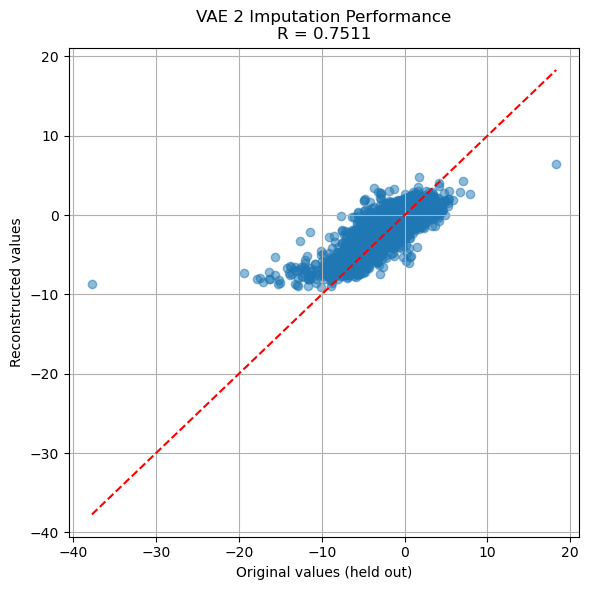


Average Pearson R over 14 seeds: 0.7914


In [12]:
seeds=[3, 7, 13, 42, 99, 123, 2024, 777, 11, 8, 323, 1234, 22, 10] #14
df=pd.read_csv('/Users/joanacorreia/Library/CloudStorage/GoogleDrive-joana.d.correia@tecnico.ulisboa.pt/Discos partilhados/Cancer Scanning manuscript 2024/data/4_Screen_zscores/MC/MC_zscores_pDNA.csv')
df_original = df.copy()
df_numeric = df.select_dtypes(include=[np.number])
print(df_original.isna().sum().sum(), "original values are NaN.")
totalr2=[]
for seed in seeds:

    df_sparse , mutations_removed, conditions_removed = induce_sparsity(df,row_frac=0.5, col_n=10,seed=seed)
    print(df_sparse.isna().sum().sum()-df_original.isna().sum().sum(), "values were set to NaN")
    print('Total non Nan values:', df_numeric.count().sum())
    print(mutations_removed)



    torch.manual_seed(seed)
    X_tensor, induced_mask, training_mask, df_numeric_columns = prepare_vae_data(df_sparse, df_original)
    vae2 = VAE2(input_dim=X_tensor.shape[1],latent_dim=4, hidden_dim=128)
    train_vae(vae2, X_tensor, training_mask, induced_mask, val_split=0.1, epochs=300, lr=1e-3)

    vae2.eval()
    with torch.no_grad():
        reconstructed, _, _ = vae2(X_tensor)

    df_numeric = df.select_dtypes(include=[np.number])
    data_array = df_numeric.values.astype(float)
    X_original = torch.tensor(data_array, dtype=torch.float32)

    original_np = X_original[induced_mask]
    reconstructed_np = reconstructed[induced_mask]
    mask_np = induced_mask.numpy()

    original_vals = original_np.numpy()
    reconstructed_vals = reconstructed_np.numpy()
    #r2 = r2_score(original_vals, reconstructed_vals)
    r, _ = scipy.stats.pearsonr(original_vals.flatten(), reconstructed_vals.flatten())
    totalr2.append(r)
    plt.figure(figsize=(6, 6))
    plt.scatter(original_vals, reconstructed_vals, alpha=0.5)
    plt.plot([original_vals.min(), original_vals.max()],[original_vals.min(), original_vals.max()],'r--') 
    plt.xlabel("Original values (held out)")
    plt.ylabel("Reconstructed values")
    plt.title(f"VAE 2 Imputation Performance\nR = {r:.4f}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.show()
average_r2 = np.mean(totalr2)
print(f"\nAverage Pearson R over {len(seeds)} seeds: {average_r2:.4f}")

In [13]:
print(f"\nAverage Pearson R over {len(seeds)} seeds: {average_r2:.4f}")


Average Pearson R over 14 seeds: 0.7914


22608 original values are NaN.
9044 values were set to NaN
Total non Nan values: 926928
Index([16378, 33057,  8806, 29985,  4671, 24905, 14424,  1522, 18380,  4056,
       ...
       44446, 22367, 10430, 41079, 30470, 36886,  9653,  9755, 29362, 29460],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0257, val_loss=0.4489
Epoch 10: train_loss=0.8065, val_loss=0.2644
Epoch 20: train_loss=0.6835, val_loss=0.2063
Epoch 30: train_loss=0.5971, val_loss=0.2152
Epoch 40: train_loss=0.5250, val_loss=0.3815
Epoch 50: train_loss=0.4699, val_loss=0.2887
Epoch 60: train_loss=0.4104, val_loss=0.2890
Epoch 70: train_loss=0.3781, val_loss=0.3044
Epoch 80: train_loss=0.3557, val_loss=0.2963
Epoch 90: train_loss=0.3387, val_loss=0.2866
Epoch 100: train_loss=0.3268, val_loss=0.2905
Epoch 110: train_loss=0.3177, val_loss=0.2834
Epoch 120: train_loss=0.3101, val_loss=0.2821
Epoch 130: train_loss=0.3035, val_loss=0.2807
Epoch 140: train_loss=0.2986, val_loss=0.2795
Epoch 150: train_loss=0.2947, val

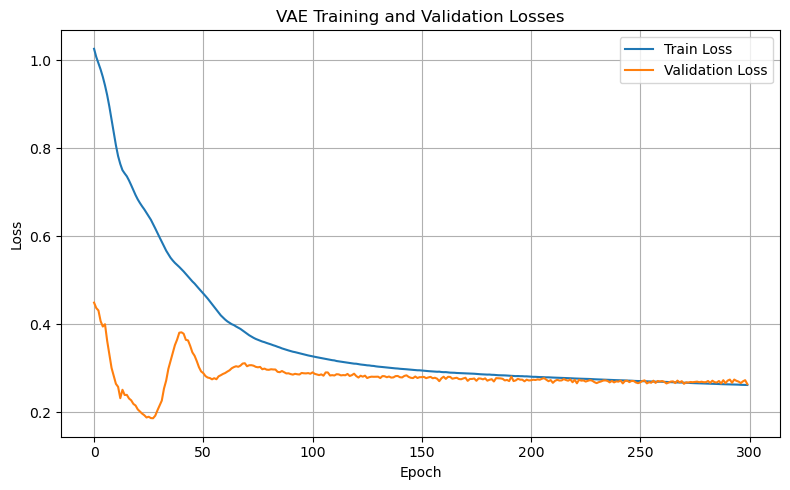

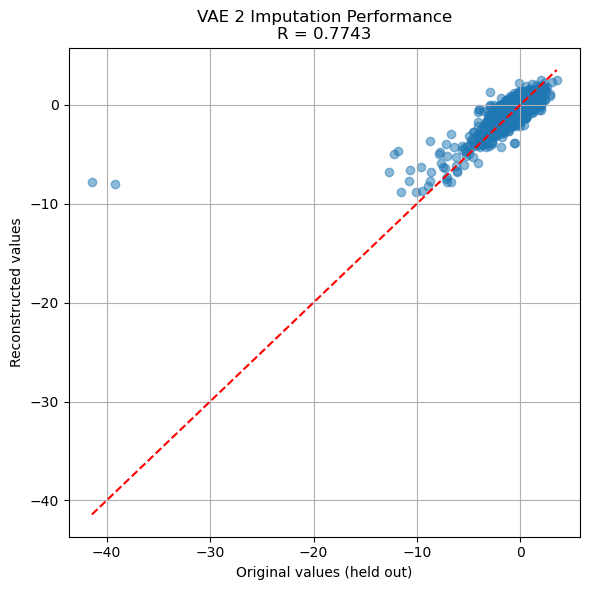

9044 values were set to NaN
Total non Nan values: 926928
Index([33180,  1544, 25860, 27946, 30199, 34996, 10563, 22824, 15438, 37829,
       ...
       43653, 32986, 12484, 41870, 16152, 12888, 15148,  7339, 25744, 15987],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0273, val_loss=0.4746
Epoch 10: train_loss=0.7995, val_loss=0.2465
Epoch 20: train_loss=0.6338, val_loss=0.1437
Epoch 30: train_loss=0.5487, val_loss=0.1691
Epoch 40: train_loss=0.5047, val_loss=0.1488
Epoch 50: train_loss=0.4594, val_loss=0.1827
Epoch 60: train_loss=0.4171, val_loss=0.2626
Epoch 70: train_loss=0.3824, val_loss=0.1757
Epoch 80: train_loss=0.3564, val_loss=0.2040
Epoch 90: train_loss=0.3409, val_loss=0.2067
Epoch 100: train_loss=0.3278, val_loss=0.1947
Epoch 110: train_loss=0.3177, val_loss=0.1907
Epoch 120: train_loss=0.3092, val_loss=0.2050
Epoch 130: train_loss=0.3026, val_loss=0.2066
Epoch 140: train_loss=0.2970, val_loss=0.2096
Epoch 150: train_loss=0.2918, val_loss=0.2159
Epoch 160: train_l

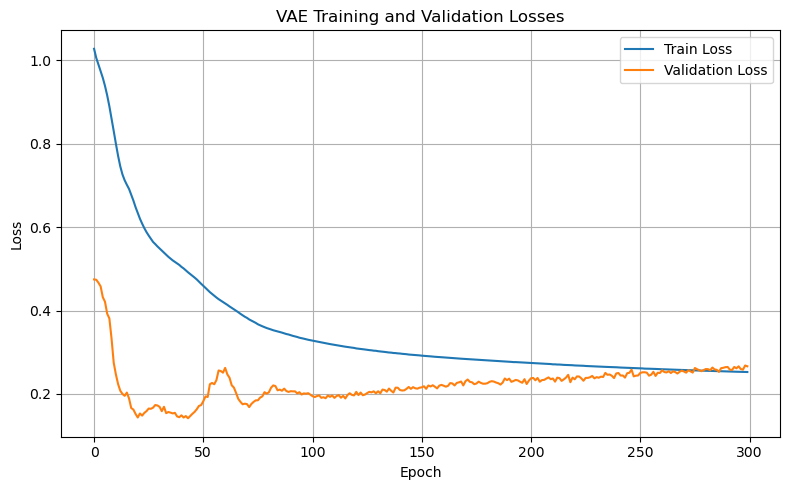

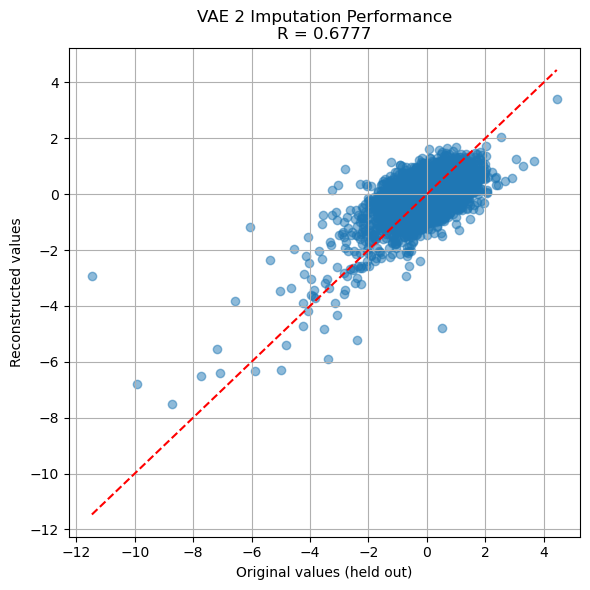

9044 values were set to NaN
Total non Nan values: 926928
Index([16159, 11807, 19922, 17897, 28017, 21241, 36855, 22738,  8793, 43170,
       ...
       14736, 17565, 44854, 23382, 14914, 26454, 27341, 22404, 42514, 39855],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0231, val_loss=0.4770
Epoch 10: train_loss=0.7958, val_loss=0.2539
Epoch 20: train_loss=0.6556, val_loss=0.1876
Epoch 30: train_loss=0.5600, val_loss=0.1915
Epoch 40: train_loss=0.4926, val_loss=0.2071
Epoch 50: train_loss=0.4371, val_loss=0.2032
Epoch 60: train_loss=0.4051, val_loss=0.2106
Epoch 70: train_loss=0.3763, val_loss=0.1995
Epoch 80: train_loss=0.3536, val_loss=0.1984
Epoch 90: train_loss=0.3376, val_loss=0.1968
Epoch 100: train_loss=0.3252, val_loss=0.1908
Epoch 110: train_loss=0.3151, val_loss=0.1927
Epoch 120: train_loss=0.3068, val_loss=0.1928
Epoch 130: train_loss=0.2997, val_loss=0.1962
Epoch 140: train_loss=0.2938, val_loss=0.1932
Epoch 150: train_loss=0.2884, val_loss=0.1946
Epoch 160: train_l

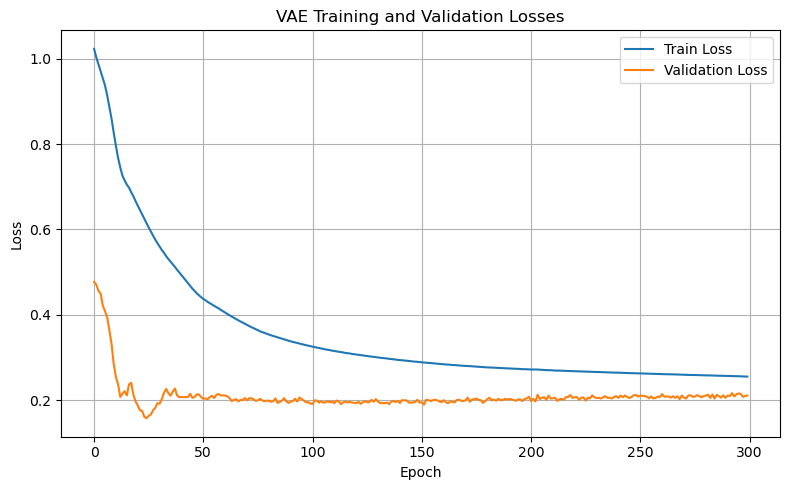

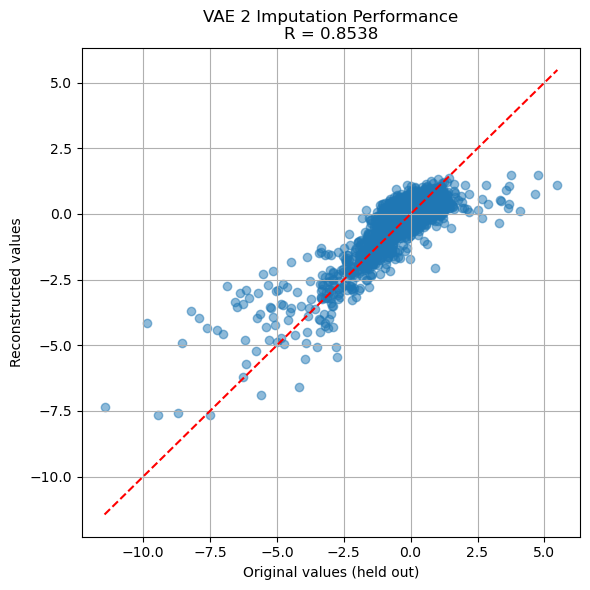

9044 values were set to NaN
Total non Nan values: 926928
Index([ 3776,  9928, 33411, 41896, 15738, 37089, 35466, 31384, 16904, 11930,
       ...
        2194, 21324, 21974, 15912,  7568, 41283,  6808, 12358, 27085, 28081],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0126, val_loss=0.5437
Epoch 10: train_loss=0.7646, val_loss=0.3080
Epoch 20: train_loss=0.6380, val_loss=0.2651
Epoch 30: train_loss=0.5445, val_loss=0.2842
Epoch 40: train_loss=0.4688, val_loss=0.3413
Epoch 50: train_loss=0.4269, val_loss=0.3627
Epoch 60: train_loss=0.3956, val_loss=0.3242
Epoch 70: train_loss=0.3676, val_loss=0.3243
Epoch 80: train_loss=0.3456, val_loss=0.3130
Epoch 90: train_loss=0.3307, val_loss=0.2997
Epoch 100: train_loss=0.3188, val_loss=0.2806
Epoch 110: train_loss=0.3097, val_loss=0.2749
Epoch 120: train_loss=0.3025, val_loss=0.2758
Epoch 130: train_loss=0.2962, val_loss=0.2724
Epoch 140: train_loss=0.2912, val_loss=0.2655
Epoch 150: train_loss=0.2868, val_loss=0.2688
Epoch 160: train_l

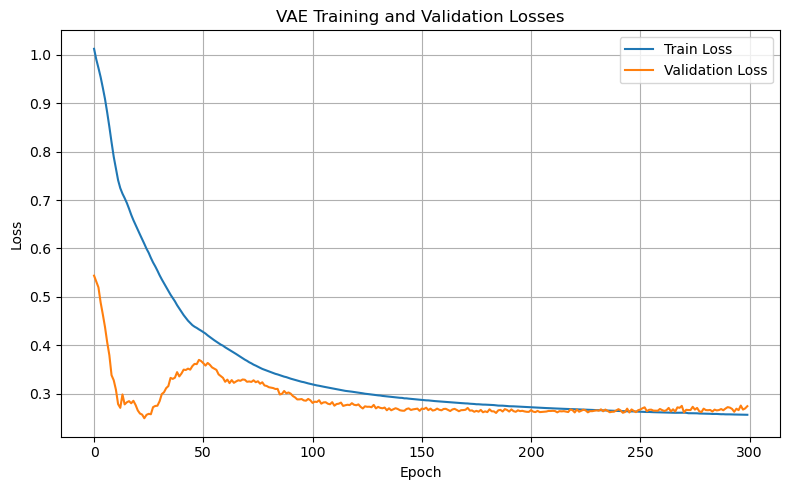

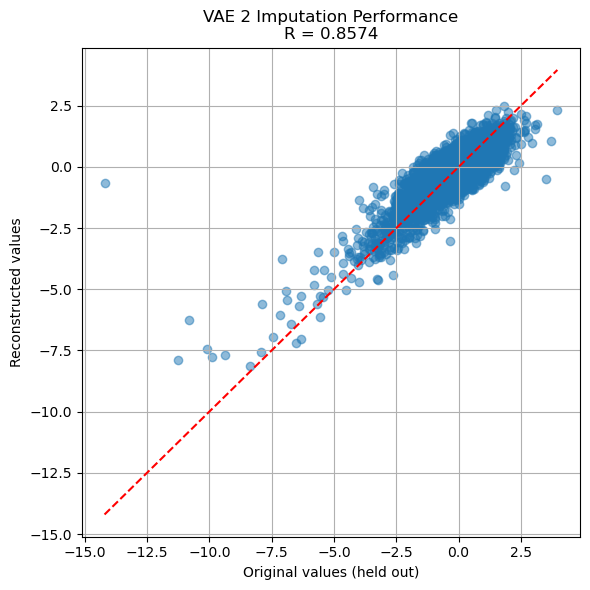

6781 values were set to NaN
Total non Nan values: 926928
Index([15638, 10798, 34315, 42356,  4923, 15025, 36095, 19088, 18739, 42347,
       ...
        6117, 30411, 14601, 40004, 24820, 37017, 19399, 38546, 32547, 21538],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0135, val_loss=0.4904
Epoch 10: train_loss=0.7532, val_loss=0.2844
Epoch 20: train_loss=0.6535, val_loss=0.2241
Epoch 30: train_loss=0.5508, val_loss=0.2620
Epoch 40: train_loss=0.4915, val_loss=0.2966
Epoch 50: train_loss=0.4369, val_loss=0.2940
Epoch 60: train_loss=0.3999, val_loss=0.3128
Epoch 70: train_loss=0.3664, val_loss=0.2800
Epoch 80: train_loss=0.3426, val_loss=0.2639
Epoch 90: train_loss=0.3261, val_loss=0.2487
Epoch 100: train_loss=0.3142, val_loss=0.2385
Epoch 110: train_loss=0.3046, val_loss=0.2398
Epoch 120: train_loss=0.2975, val_loss=0.2332
Epoch 130: train_loss=0.2913, val_loss=0.2342
Epoch 140: train_loss=0.2863, val_loss=0.2370
Epoch 150: train_loss=0.2823, val_loss=0.2283
Epoch 160: train_l

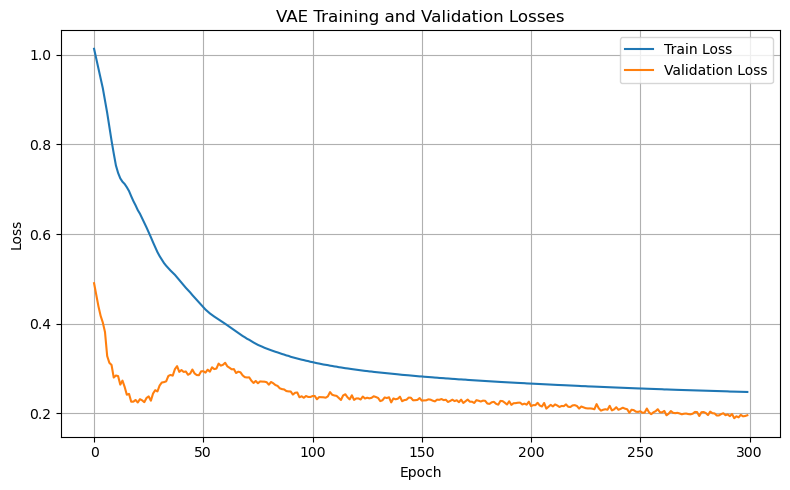

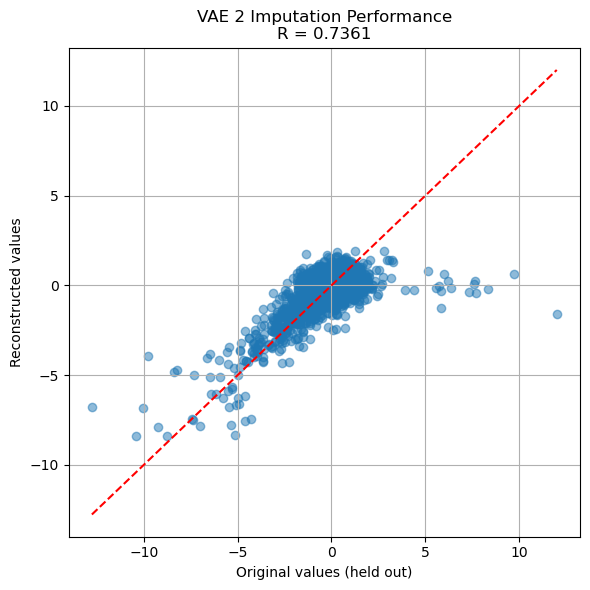

9044 values were set to NaN
Total non Nan values: 926928
Index([27848, 25245, 27507,  4795, 23864, 35667,  8907,  5573, 15187, 30127,
       ...
       22899, 19284,  9611, 34544, 42050, 21470, 19178, 21277,  8498, 40516],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0235, val_loss=0.5046
Epoch 10: train_loss=0.7768, val_loss=0.2640
Epoch 20: train_loss=0.6502, val_loss=0.1892
Epoch 30: train_loss=0.5558, val_loss=0.2218
Epoch 40: train_loss=0.5077, val_loss=0.1964
Epoch 50: train_loss=0.4551, val_loss=0.1928
Epoch 60: train_loss=0.4019, val_loss=0.2584
Epoch 70: train_loss=0.3709, val_loss=0.2210
Epoch 80: train_loss=0.3505, val_loss=0.2043
Epoch 90: train_loss=0.3350, val_loss=0.2116
Epoch 100: train_loss=0.3238, val_loss=0.2103
Epoch 110: train_loss=0.3147, val_loss=0.2129
Epoch 120: train_loss=0.3076, val_loss=0.2136
Epoch 130: train_loss=0.3011, val_loss=0.2189
Epoch 140: train_loss=0.2958, val_loss=0.2206
Epoch 150: train_loss=0.2912, val_loss=0.2144
Epoch 160: train_l

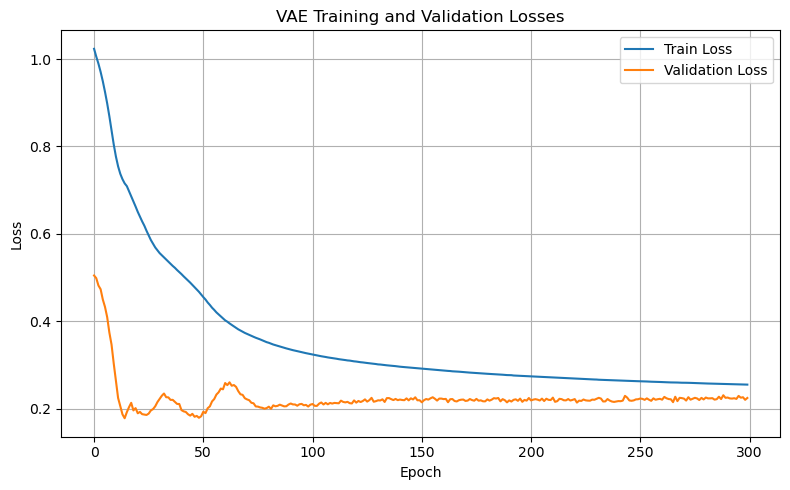

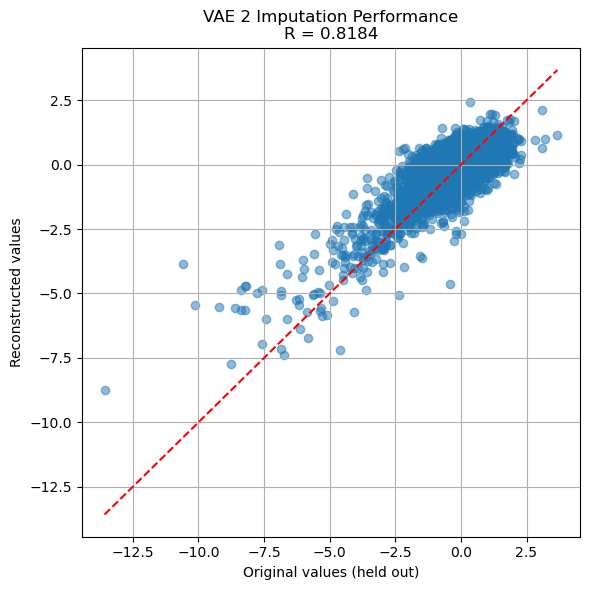

9044 values were set to NaN
Total non Nan values: 926928
Index([16806, 10593, 29122, 18880,   216, 34496, 17153, 34285,  1985,  3772,
       ...
       41144,  7693, 20407, 36803, 23103, 37444, 29091, 42957, 26974,  2215],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0282, val_loss=0.4398
Epoch 10: train_loss=0.7897, val_loss=0.2610
Epoch 20: train_loss=0.6618, val_loss=0.2007
Epoch 30: train_loss=0.5583, val_loss=0.2604
Epoch 40: train_loss=0.4820, val_loss=0.3161
Epoch 50: train_loss=0.4370, val_loss=0.2753
Epoch 60: train_loss=0.4074, val_loss=0.2880
Epoch 70: train_loss=0.3826, val_loss=0.2671
Epoch 80: train_loss=0.3607, val_loss=0.2675
Epoch 90: train_loss=0.3448, val_loss=0.2552
Epoch 100: train_loss=0.3320, val_loss=0.2464
Epoch 110: train_loss=0.3218, val_loss=0.2396
Epoch 120: train_loss=0.3131, val_loss=0.2422
Epoch 130: train_loss=0.3060, val_loss=0.2382
Epoch 140: train_loss=0.2998, val_loss=0.2378
Epoch 150: train_loss=0.2946, val_loss=0.2414
Epoch 160: train_l

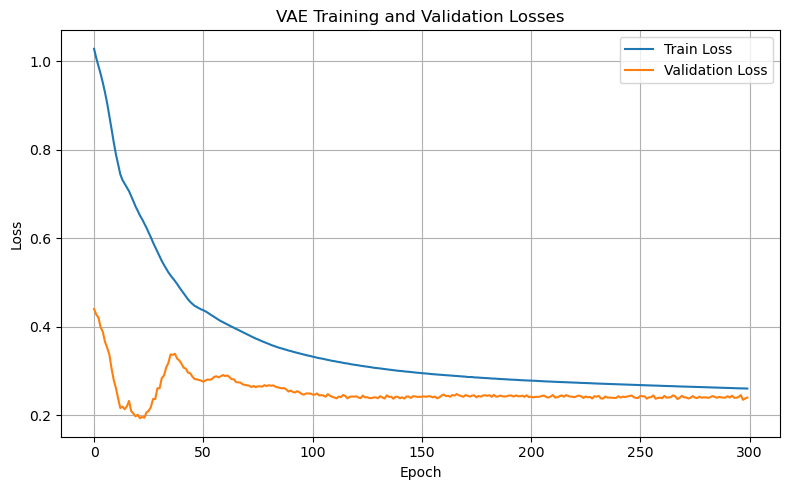

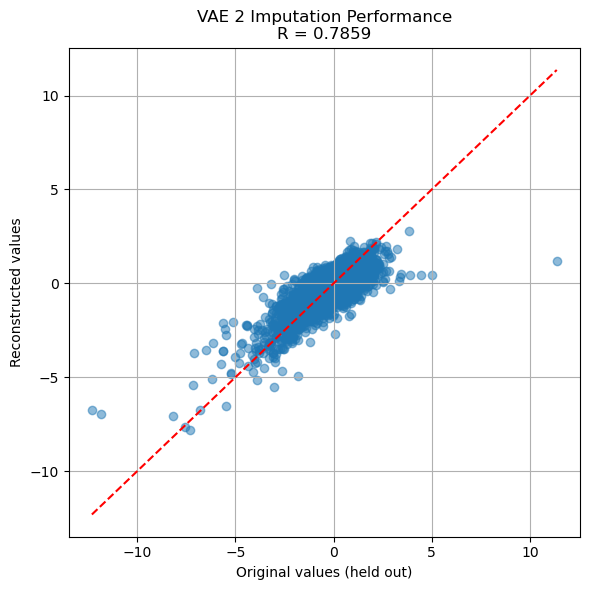

9044 values were set to NaN
Total non Nan values: 926928
Index([32884, 30176, 10167, 26633, 14875, 10528, 35116, 33299, 13039, 27379,
       ...
       21637, 30521, 16147, 25466, 10907, 30470, 37053, 40293, 35196,  8384],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0329, val_loss=0.4762
Epoch 10: train_loss=0.8010, val_loss=0.2807
Epoch 20: train_loss=0.6525, val_loss=0.2425
Epoch 30: train_loss=0.5585, val_loss=0.2820
Epoch 40: train_loss=0.5018, val_loss=0.2695
Epoch 50: train_loss=0.4438, val_loss=0.2749
Epoch 60: train_loss=0.4072, val_loss=0.2721
Epoch 70: train_loss=0.3778, val_loss=0.2754
Epoch 80: train_loss=0.3573, val_loss=0.2610
Epoch 90: train_loss=0.3408, val_loss=0.2557
Epoch 100: train_loss=0.3287, val_loss=0.2448
Epoch 110: train_loss=0.3190, val_loss=0.2588
Epoch 120: train_loss=0.3113, val_loss=0.2535
Epoch 130: train_loss=0.3052, val_loss=0.2632
Epoch 140: train_loss=0.3002, val_loss=0.2595
Epoch 150: train_loss=0.2959, val_loss=0.2613
Epoch 160: train_l

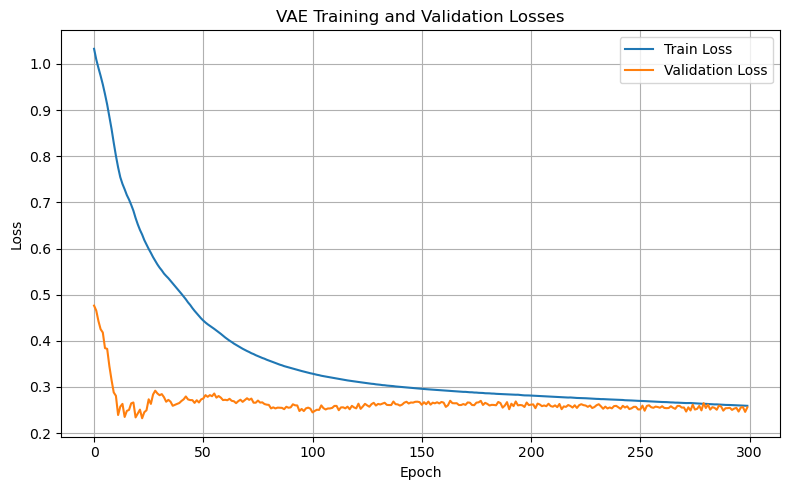

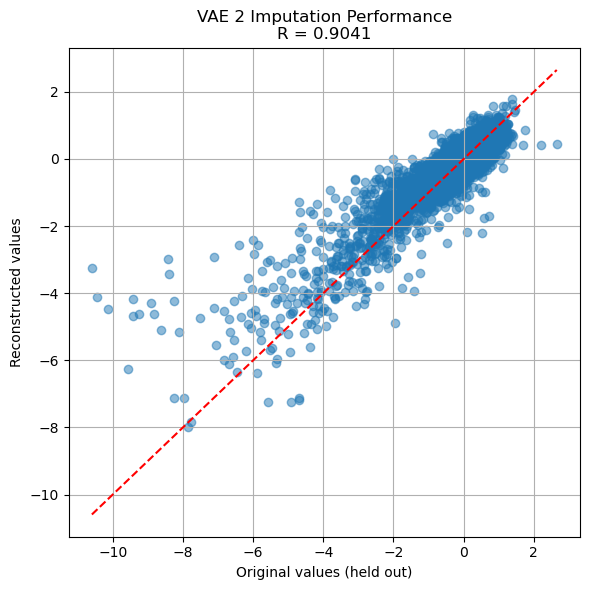

9044 values were set to NaN
Total non Nan values: 926928
Index([ 5630, 20258, 10111, 23846, 26684, 24479, 15273,   302, 17828, 35182,
       ...
        7063, 37966,   192, 39872, 30167, 35898, 18545, 22723,  9718, 21834],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0154, val_loss=0.4054
Epoch 10: train_loss=0.7710, val_loss=0.2120
Epoch 20: train_loss=0.6598, val_loss=0.1215
Epoch 30: train_loss=0.5619, val_loss=0.1756
Epoch 40: train_loss=0.4960, val_loss=0.2096
Epoch 50: train_loss=0.4384, val_loss=0.2058
Epoch 60: train_loss=0.4010, val_loss=0.2653
Epoch 70: train_loss=0.3710, val_loss=0.2508
Epoch 80: train_loss=0.3501, val_loss=0.2695
Epoch 90: train_loss=0.3354, val_loss=0.2722
Epoch 100: train_loss=0.3239, val_loss=0.2669
Epoch 110: train_loss=0.3144, val_loss=0.2704
Epoch 120: train_loss=0.3072, val_loss=0.2698
Epoch 130: train_loss=0.3011, val_loss=0.2680
Epoch 140: train_loss=0.2958, val_loss=0.2643
Epoch 150: train_loss=0.2912, val_loss=0.2587
Epoch 160: train_l

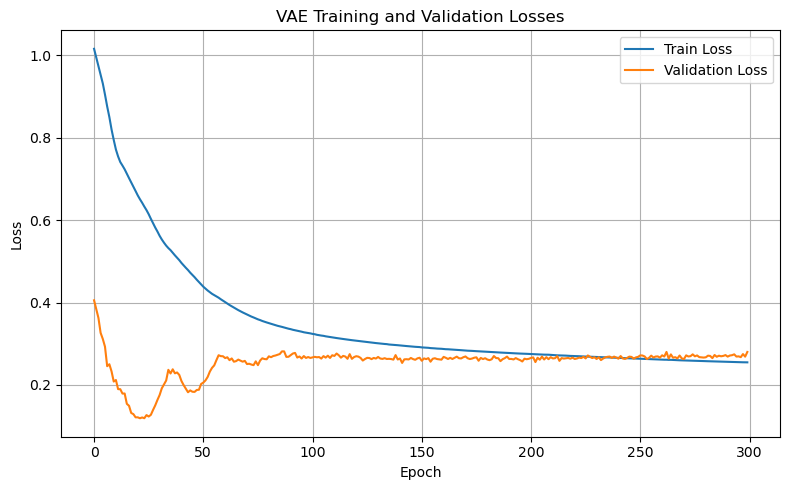

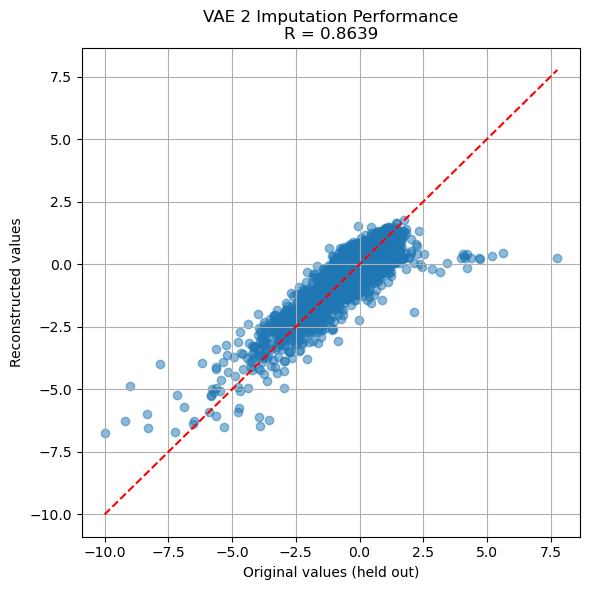

9044 values were set to NaN
Total non Nan values: 926928
Index([38499, 10196, 23677, 17783,  1376, 23204, 37330, 24250, 28032, 30742,
       ...
       34090,  5155,   325, 38788, 31033, 19250, 16294, 31995, 18851, 32001],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0117, val_loss=0.3346
Epoch 10: train_loss=0.7524, val_loss=0.1690
Epoch 20: train_loss=0.6238, val_loss=0.1570
Epoch 30: train_loss=0.5449, val_loss=0.1874
Epoch 40: train_loss=0.4993, val_loss=0.1805
Epoch 50: train_loss=0.4433, val_loss=0.2296
Epoch 60: train_loss=0.4082, val_loss=0.2849
Epoch 70: train_loss=0.3766, val_loss=0.2199
Epoch 80: train_loss=0.3500, val_loss=0.2483
Epoch 90: train_loss=0.3326, val_loss=0.2582
Epoch 100: train_loss=0.3199, val_loss=0.2478
Epoch 110: train_loss=0.3102, val_loss=0.2471
Epoch 120: train_loss=0.3023, val_loss=0.2504
Epoch 130: train_loss=0.2967, val_loss=0.2504
Epoch 140: train_loss=0.2919, val_loss=0.2518
Epoch 150: train_loss=0.2877, val_loss=0.2433
Epoch 160: train_l

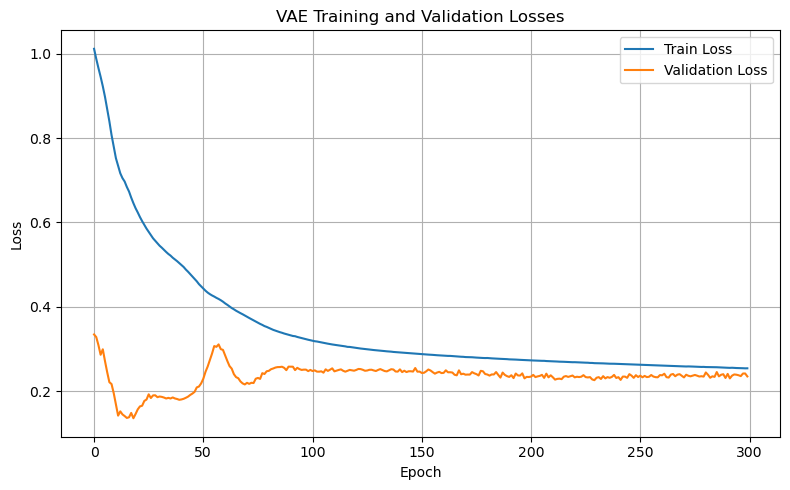

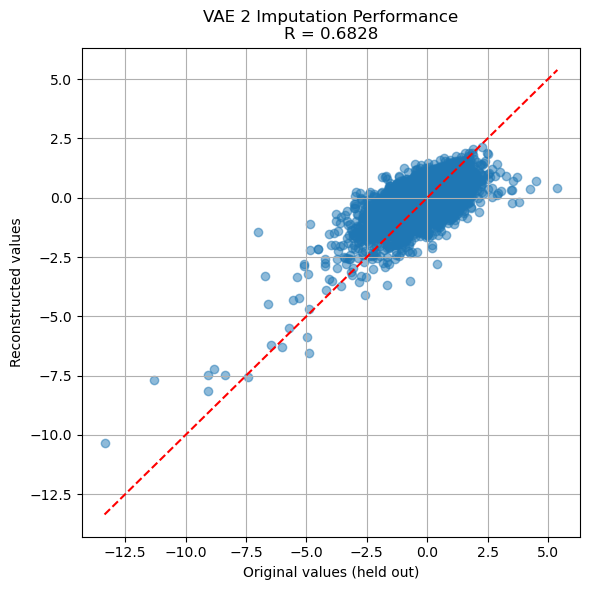

9044 values were set to NaN
Total non Nan values: 926928
Index([17617, 43971, 34035, 32315, 15193, 23872, 12538, 23293, 22059, 21910,
       ...
       35632, 16517, 21042,  4062, 42394, 41721, 26668, 25121, 18061,  7260],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0237, val_loss=0.4325
Epoch 10: train_loss=0.7599, val_loss=0.2029
Epoch 20: train_loss=0.6225, val_loss=0.2220
Epoch 30: train_loss=0.5436, val_loss=0.2129
Epoch 40: train_loss=0.4886, val_loss=0.1882
Epoch 50: train_loss=0.4372, val_loss=0.1900
Epoch 60: train_loss=0.3984, val_loss=0.1914
Epoch 70: train_loss=0.3706, val_loss=0.1961
Epoch 80: train_loss=0.3510, val_loss=0.1932
Epoch 90: train_loss=0.3356, val_loss=0.1882
Epoch 100: train_loss=0.3240, val_loss=0.1923
Epoch 110: train_loss=0.3154, val_loss=0.1938
Epoch 120: train_loss=0.3084, val_loss=0.1985
Epoch 130: train_loss=0.3026, val_loss=0.1935
Epoch 140: train_loss=0.2977, val_loss=0.1923
Epoch 150: train_loss=0.2933, val_loss=0.1922
Epoch 160: train_l

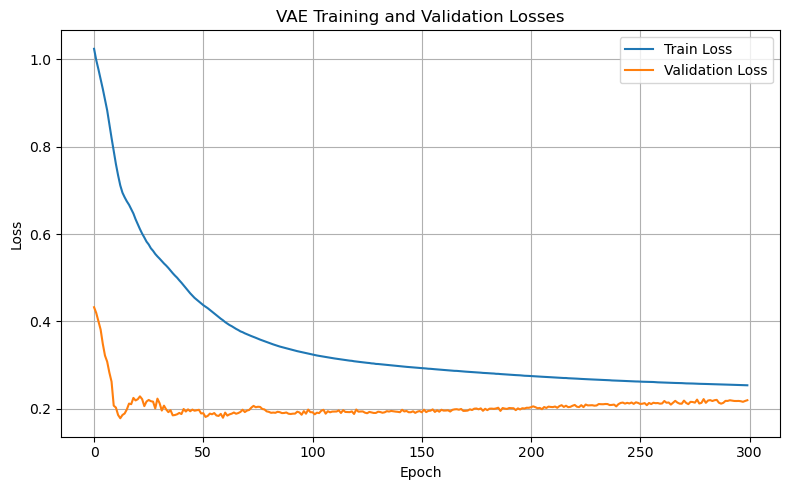

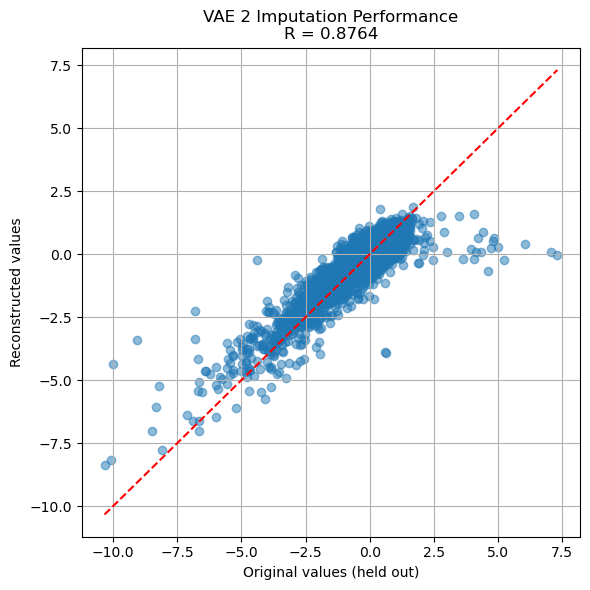

9044 values were set to NaN
Total non Nan values: 926928
Index([10329, 38964, 10889, 33407, 33955, 31567, 15591, 39432, 38454, 29480,
       ...
       43416, 40966, 32445,  7923, 36931,  2804, 11644,  1087, 34207, 24063],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0340, val_loss=0.2819
Epoch 10: train_loss=0.7866, val_loss=0.1626
Epoch 20: train_loss=0.6585, val_loss=0.1205
Epoch 30: train_loss=0.5643, val_loss=0.1436
Epoch 40: train_loss=0.4918, val_loss=0.2239
Epoch 50: train_loss=0.4362, val_loss=0.2770
Epoch 60: train_loss=0.4017, val_loss=0.2637
Epoch 70: train_loss=0.3696, val_loss=0.2498
Epoch 80: train_loss=0.3494, val_loss=0.2721
Epoch 90: train_loss=0.3335, val_loss=0.2534
Epoch 100: train_loss=0.3224, val_loss=0.2386
Epoch 110: train_loss=0.3125, val_loss=0.2472
Epoch 120: train_loss=0.3049, val_loss=0.2360
Epoch 130: train_loss=0.2982, val_loss=0.2323
Epoch 140: train_loss=0.2926, val_loss=0.2315
Epoch 150: train_loss=0.2876, val_loss=0.2335
Epoch 160: train_l

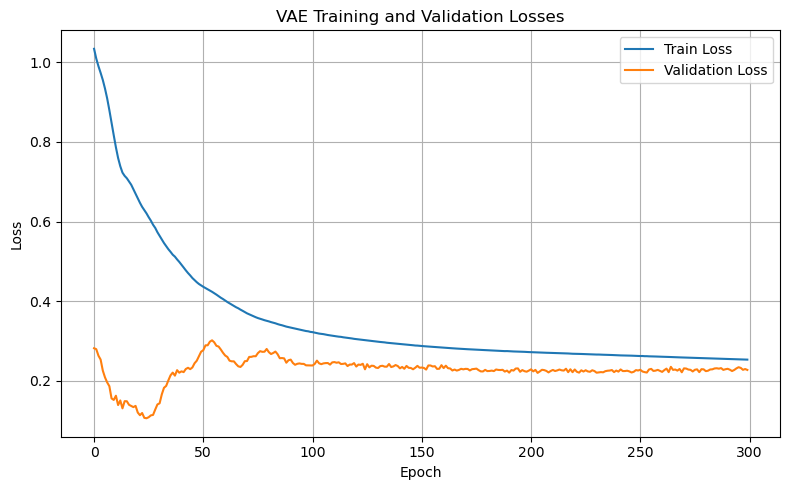

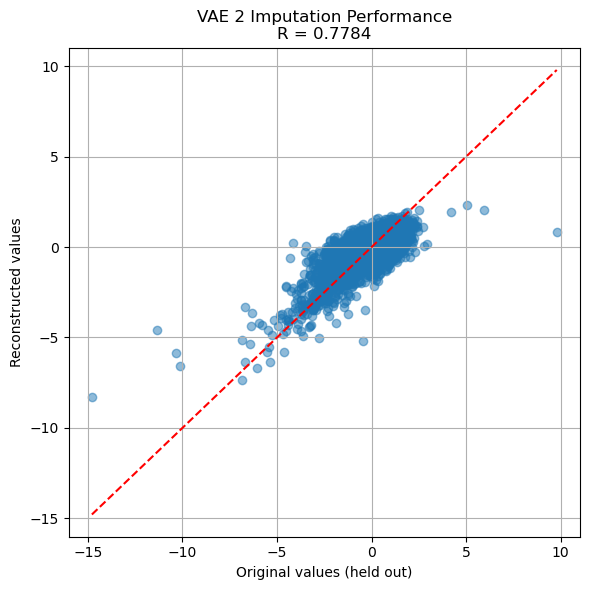

9044 values were set to NaN
Total non Nan values: 926928
Index([ 4793,  7650, 40013, 16743, 12188,   507, 37279, 44211, 31310, 31294,
       ...
       24297, 37172,  4410, 20650,  1251, 26821, 36682, 24121, 40329,  7830],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0261, val_loss=0.4886
Epoch 10: train_loss=0.8097, val_loss=0.3158
Epoch 20: train_loss=0.6463, val_loss=0.2568
Epoch 30: train_loss=0.5516, val_loss=0.3193
Epoch 40: train_loss=0.4786, val_loss=0.2894
Epoch 50: train_loss=0.4301, val_loss=0.3141
Epoch 60: train_loss=0.3907, val_loss=0.2977
Epoch 70: train_loss=0.3635, val_loss=0.2876
Epoch 80: train_loss=0.3435, val_loss=0.2837
Epoch 90: train_loss=0.3287, val_loss=0.2690
Epoch 100: train_loss=0.3164, val_loss=0.2655
Epoch 110: train_loss=0.3065, val_loss=0.2543
Epoch 120: train_loss=0.2987, val_loss=0.2542
Epoch 130: train_loss=0.2925, val_loss=0.2514
Epoch 140: train_loss=0.2875, val_loss=0.2482
Epoch 150: train_loss=0.2830, val_loss=0.2523
Epoch 160: train_l

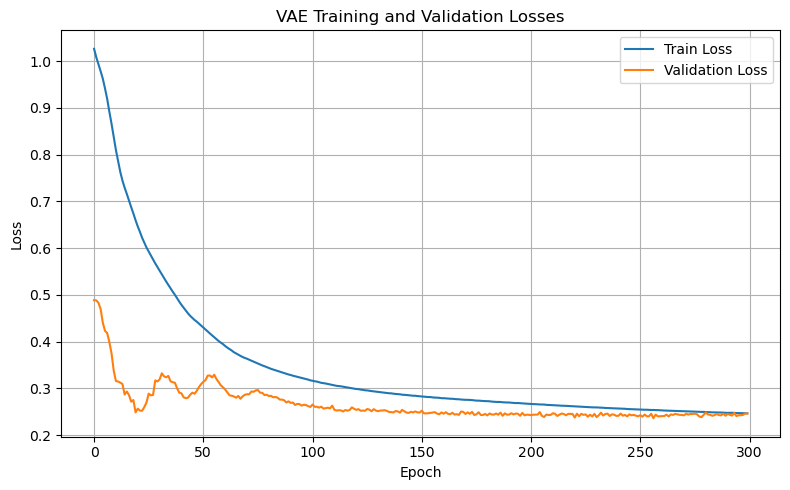

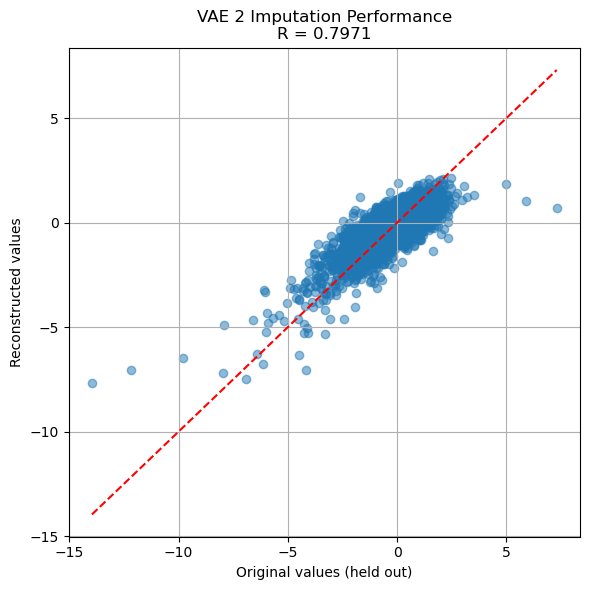

9044 values were set to NaN
Total non Nan values: 926928
Index([37280,  8403, 16544, 19900, 15498, 10375,  4001, 16969, 40084, 37991,
       ...
        2289, 25891, 13198, 33367, 20755, 13234, 28493, 33758, 30781, 14981],
      dtype='int64', length=4522)
Epoch 0: train_loss=1.0224, val_loss=0.4313
Epoch 10: train_loss=0.8302, val_loss=0.2645
Epoch 20: train_loss=0.6558, val_loss=0.1548
Epoch 30: train_loss=0.5519, val_loss=0.1255
Epoch 40: train_loss=0.4798, val_loss=0.1409
Epoch 50: train_loss=0.4348, val_loss=0.1833
Epoch 60: train_loss=0.4020, val_loss=0.1596
Epoch 70: train_loss=0.3720, val_loss=0.1544
Epoch 80: train_loss=0.3488, val_loss=0.1548
Epoch 90: train_loss=0.3339, val_loss=0.1493
Epoch 100: train_loss=0.3221, val_loss=0.1465
Epoch 110: train_loss=0.3128, val_loss=0.1420
Epoch 120: train_loss=0.3055, val_loss=0.1378
Epoch 130: train_loss=0.2992, val_loss=0.1348
Epoch 140: train_loss=0.2944, val_loss=0.1304
Epoch 150: train_loss=0.2901, val_loss=0.1275
Epoch 160: train_l

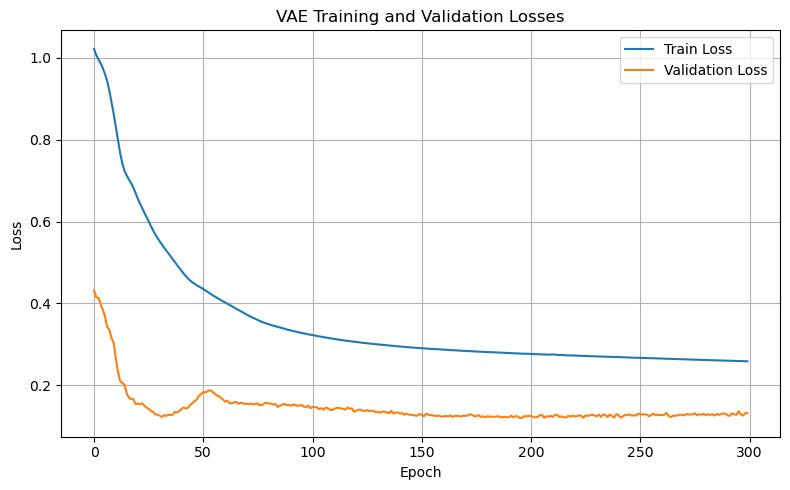

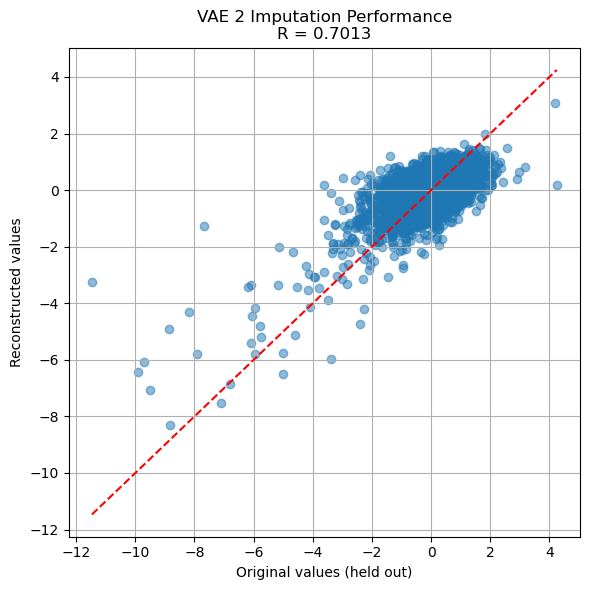


Average Pearson R over 14 seeds: 0.7934


In [14]:
seeds=[3, 7, 13, 42, 99, 123, 2024, 777, 11, 8, 323, 1234, 22, 10] #14
df=pd.read_csv('/Users/joanacorreia/Library/CloudStorage/GoogleDrive-joana.d.correia@tecnico.ulisboa.pt/Discos partilhados/Cancer Scanning manuscript 2024/data/4_Screen_zscores/MC/MC_zscores_pDNA.csv')
df_original = df.copy()
df_numeric = df.select_dtypes(include=[np.number])
print(df_original.isna().sum().sum(), "original values are NaN.")
totalr2=[]
for seed in seeds:

    df_sparse , mutations_removed, conditions_removed = induce_sparsity(df,row_frac=0.1, col_n=2,seed=seed)
    print(df_sparse.isna().sum().sum()-df_original.isna().sum().sum(), "values were set to NaN")
    print('Total non Nan values:', df_numeric.count().sum())
    print(mutations_removed)



    torch.manual_seed(seed)
    X_tensor, induced_mask, training_mask, df_numeric_columns = prepare_vae_data(df_sparse, df_original)
    vae2 = VAE2(input_dim=X_tensor.shape[1],latent_dim=4, hidden_dim=128)
    train_vae(vae2, X_tensor, training_mask, induced_mask, val_split=0.1, epochs=300, lr=1e-3)

    vae2.eval()
    with torch.no_grad():
        reconstructed, _, _ = vae2(X_tensor)

    df_numeric = df.select_dtypes(include=[np.number])
    data_array = df_numeric.values.astype(float)
    X_original = torch.tensor(data_array, dtype=torch.float32)

    original_np = X_original[induced_mask]
    reconstructed_np = reconstructed[induced_mask]
    mask_np = induced_mask.numpy()

    original_vals = original_np.numpy()
    reconstructed_vals = reconstructed_np.numpy()
    #r2 = r2_score(original_vals, reconstructed_vals)
    r, _ = scipy.stats.pearsonr(original_vals.flatten(), reconstructed_vals.flatten())
    totalr2.append(r)
    plt.figure(figsize=(6, 6))
    plt.scatter(original_vals, reconstructed_vals, alpha=0.5)
    plt.plot([original_vals.min(), original_vals.max()],[original_vals.min(), original_vals.max()],'r--') 
    plt.xlabel("Original values (held out)")
    plt.ylabel("Reconstructed values")
    plt.title(f"VAE 2 Imputation Performance\nR = {r:.4f}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.show()
average_r2 = np.mean(totalr2)
print(f"\nAverage Pearson R over {len(seeds)} seeds: {average_r2:.4f}")